# Spatial WX extension of the two-stage LightGBM

既存の二段階 LightGBM と、外生的な近隣平均 WX を加えたモデルを、同じ Spatial OOF で比較します。

- ベースライン: 既存の二段階 LightGBM
- WXモデル: ベースライン + 50 km / 100 km の近隣平均
- 近隣平均の候補: 人口密度、都市・港への移動時間、rainfed potential、河川水条件
- 評価: combined two-stage fraction の R2、RMSE、MAE
- 診断: 残差の k近傍 Moran's I

緯度・経度そのものは説明変数に入れません。WX は cropland fraction を使わず、既存の外生的特徴量ラスタだけから作ります。元のノートブックで features_cache を作成してから実行してください。

# Spatial WX extension of the two-stage LightGBM

## セル番号・実行順

このノートブックのセル番号は、Jupyter上で上から数える**0始まりの管理番号**です。

| セル | 内容 | 扱い |
|---:|---|---|
| 0–13 | データ読み込み、WX作成、baseline/WXのSpatial OOF、指標・Moran's I | 実行 |
| 14–19 | baseline/WXだけを対象にした旧SHAP | **削除候補・実行しない** |
| 20 | raw_crop / raw_crop_wx再推定の見出し | 説明 |
| 21 | raw_crop / raw_crop_wxの5-fold OOF再推定 | **実行** |
| 22 | GLOBAL R²・面積加重R²・fold別比較の見出し | 説明 |
| 23 | raw_crop_wxを含むR²比較 | **セル21の後に実行** |

### 今回の目的

今回の最終候補は `raw_crop_wx` です。セル14–19は旧モデル（baseline/WX）のSHAPであり、今回の分析には使いません。セル21を実行してからセル23を実行してください。

- ベースライン：既存特徴量
- WX：既存特徴量 + log形式の近隣平均
- raw_crop：crop-potentialをraw値・存在フラグ等で再構成
- raw_crop_wx：raw_crop + WX

In [1]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)
from sklearn.neighbors import BallTree
from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path(r"C:\masterresearch\Comparative_advantage")
GAEZ_DIR = ROOT / "GAEZ"
HYDE_DIR = ROOT / "HYDE3.4"
CROPLAND_DIR = HYDE_DIR / "cropland_npys"
DIST_DIR = ROOT / "distance_to_cities"
GLOFAS_DIR = ROOT / "GloFAS" / "processed_5min"
FEATURE_CACHE = GAEZ_DIR / "CroplandRegression" / "features_cache"
OUTPUT_DIR = GAEZ_DIR / "CroplandRegression" / "spatial_wx_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
YEAR = 2024
PRESENCE_THRESHOLD = 0.01
N_POS_SAMPLE = 120_000
N_ZERO_SAMPLE = 120_000
N_SPLITS = 5

WX_RADII_KM = (50, 100)
WX_SOURCE_FEATURES = [
    "log_pop_density_2024",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_rainfed_value_top5",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_2020",
]
INCLUDE_SLOPE_WX = False
MIN_VALID_NEIGHBOR_FRACTION = 0.25
SAVE_WX_RASTERS = True

EARTH_RADIUS_KM = 6371.0088
MORAN_K = 8
MORAN_MAX_N = 50_000


def load_cache(*names):
    for name in names:
        path = FEATURE_CACHE / name
        if path.exists():
            print("load cache:", path.name)
            return np.load(path, mmap_mode="r")
    raise FileNotFoundError(
        "Required cache not found: " + ", ".join(names)
    )


def safe_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.where(np.isfinite(values) & (values > 0), values, 0.0)
    return np.log1p(values).astype(np.float32)


lat = np.load(CROPLAND_DIR / "lat.npy")
lon = np.load(CROPLAND_DIR / "lon.npy")
SHAPE = (len(lat), len(lon))

cropland_raw = np.load(
    CROPLAND_DIR / "cropland_fraction_1950_2024.npy",
    mmap_mode="r",
)
years = np.load(CROPLAND_DIR / "years.npy")
year_index = int(np.where(years == YEAR)[0][0])
cropland_2024 = np.asarray(cropland_raw[year_index], dtype=np.float32).copy()
cropland_2024[~np.isfinite(cropland_2024)] = np.nan

population_density_2024 = load_cache("population_density_2024.npy")
elevation_m = load_cache("elevation_5min.npy")
slope = load_cache("slope_5min.npy")
exclusion = load_cache("exclusion_5min_mode.npy")
city_time_20k_min = np.load(DIST_DIR / "cities_10_1_12deg_min.npy", mmap_mode="r")
port_time_any_min = np.load(DIST_DIR / "ports_05_1_12deg_min.npy", mmap_mode="r")
glofas_p10 = np.load(GLOFAS_DIR / "p10_discharge_max_5min_2020.npy", mmap_mode="r")
distance_river_gt10 = np.load(
    GLOFAS_DIR / "distance_to_reliable_river_p10_gt_10_m3s_km_5min_2020.npy",
    mmap_mode="r",
)
rainfed_value_top5 = load_cache(
    "rainfed_value_top5_usd_per_ha_checked_36crops.npy",
    "rainfed_value_top5_checked_36crops.npy",
)
irrigated_value_top5 = load_cache(
    "irrigated_value_top5_usd_per_ha_checked_36crops.npy",
    "irrigated_value_top5_checked_36crops.npy",
)
rainfed_calorie_top5 = load_cache(
    "rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "rainfed_calorie_top5_checked_36crops.npy",
)
irrigated_calorie_top5 = load_cache(
    "irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "irrigated_calorie_top5_checked_36crops.npy",
)

land_mask = (
    np.isfinite(elevation_m)
    & np.isfinite(cropland_2024)
    & np.isfinite(population_density_2024)
    & (population_density_2024 >= 0)
)
presence = land_mask & (cropland_2024 > PRESENCE_THRESHOLD)

rng = np.random.default_rng(RANDOM_SEED)
pos_flat = np.flatnonzero(presence.ravel())
zero_flat = np.flatnonzero((land_mask & ~presence).ravel())
pos_sample = rng.choice(pos_flat, min(N_POS_SAMPLE, len(pos_flat)), replace=False)
zero_sample = rng.choice(zero_flat, min(N_ZERO_SAMPLE, len(zero_flat)), replace=False)
sample_flat = np.concatenate([pos_sample, zero_sample])
rng.shuffle(sample_flat)
rows, cols = np.unravel_index(sample_flat, SHAPE)


def take(array):
    return np.asarray(array[rows, cols])


sample = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    "lat": lat[rows].astype(np.float32),
    "lon": lon[cols].astype(np.float32),
    "cropland_fraction": take(cropland_2024).astype(np.float32),
    "presence": (take(cropland_2024) > PRESENCE_THRESHOLD).astype(np.uint8),
    "elevation_m": take(elevation_m).astype(np.float32),
    "slope": take(slope).astype(np.float32),
    "exclusion_class": np.nan_to_num(take(exclusion), nan=-1).astype(np.int16),
    "log_pop_density_2024": safe_log1p(take(population_density_2024)),
    "log_city_time_20k_min": safe_log1p(take(city_time_20k_min)),
    "log_port_time_any_min": safe_log1p(take(port_time_any_min)),
    "log_glofas_p10_2020": safe_log1p(take(glofas_p10)),
    "log_distance_river_gt10_2020": safe_log1p(take(distance_river_gt10)),
    "log_rainfed_value_top5": safe_log1p(take(rainfed_value_top5)),
    "log_rainfed_calorie_top5": safe_log1p(take(rainfed_calorie_top5)),
    "log_irrigation_value_gain_top5": safe_log1p(
        np.maximum(take(irrigated_value_top5) - take(rainfed_value_top5), 0)
    ),
    "log_irrigation_calorie_gain_top5": safe_log1p(
        np.maximum(take(irrigated_calorie_top5) - take(rainfed_calorie_top5), 0)
    ),
}).replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

sample["spatial_block"] = (
    np.floor((sample["lat"] + 90) / 10).astype(int) * 36
    + np.floor((sample["lon"] + 180) / 10).astype(int)
)

base_feature_cols = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_pop_density_2024",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_2020",
    "log_rainfed_value_top5",
    "log_rainfed_calorie_top5",
    "log_irrigation_value_gain_top5",
    "log_irrigation_calorie_gain_top5",
]

print("grid:", SHAPE)
print("sample rows:", len(sample))
print("sample presence share:", float(sample["presence"].mean()))

load cache: population_density_2024.npy
load cache: elevation_5min.npy
load cache: slope_5min.npy
load cache: exclusion_5min_mode.npy
load cache: rainfed_value_top5_usd_per_ha_checked_36crops.npy
load cache: irrigated_value_top5_usd_per_ha_checked_36crops.npy
load cache: rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy
load cache: irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy
grid: (2160, 4320)
sample rows: 240000
sample presence share: 0.5


## 1. 50 km / 100 km の WX を作る

5分グリッド上で、緯度方向は一定幅、経度方向は緯度に応じて幅を変える矩形近似を使います。経度は全球ラップアラウンドです。計算量とファイル容量が大きいため、各 WX ラスタは output フォルダにキャッシュします。

In [2]:
def _rolling_sum_horizontal(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    extended = np.concatenate(
        [values[:, -half_width:], values, values[:, :half_width]],
        axis=1,
    )
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((values.shape[0], 1), dtype=np.float64),
            np.cumsum(extended, axis=1, dtype=np.float64),
        ],
        axis=1,
    )
    return (cumulative[:, width:] - cumulative[:, :-width]).astype(np.float32)


def _rolling_sum_vertical(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    padded = np.pad(values, ((half_width, half_width), (0, 0)), mode="edge")
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((1, values.shape[1]), dtype=np.float64),
            np.cumsum(padded, axis=0, dtype=np.float64),
        ],
        axis=0,
    )
    return (cumulative[width:, :] - cumulative[:-width, :]).astype(np.float32)


def latitude_aware_box_mean(values, lat_values, radius_km, min_valid_fraction=0.25):
    values = np.asarray(values, dtype=np.float32)
    if values.shape != SHAPE:
        raise ValueError(f"Unexpected raster shape: {values.shape}; expected {SHAPE}")

    lat_step_deg = float(np.median(np.abs(np.diff(lat_values))))
    lon_step_deg = float(np.median(np.abs(np.diff(lon))))
    km_per_degree = EARTH_RADIUS_KM * np.pi / 180.0
    half_lat = max(1, int(np.ceil(radius_km / (km_per_degree * lat_step_deg))))

    cos_lat = np.clip(np.cos(np.deg2rad(lat_values)), 1e-6, None)
    half_lon_by_row = np.ceil(
        radius_km / (km_per_degree * cos_lat * lon_step_deg)
    ).astype(np.int32)
    half_lon_by_row = np.minimum(half_lon_by_row, values.shape[1] // 2 - 1)

    finite = np.isfinite(values)
    filled = np.where(finite, values, 0).astype(np.float32)
    counts = finite.astype(np.float32)
    horizontal_sum = np.zeros_like(filled, dtype=np.float32)
    horizontal_count = np.zeros_like(counts, dtype=np.float32)

    for half_lon in np.unique(half_lon_by_row):
        row_indices = np.flatnonzero(half_lon_by_row == half_lon)
        horizontal_sum[row_indices] = _rolling_sum_horizontal(
            filled[row_indices], int(half_lon)
        )
        horizontal_count[row_indices] = _rolling_sum_horizontal(
            counts[row_indices], int(half_lon)
        )

    vertical_sum = _rolling_sum_vertical(horizontal_sum, half_lat)
    vertical_count = _rolling_sum_vertical(horizontal_count, half_lat)

    row_width = (2 * half_lon_by_row + 1).astype(np.float64)
    padded_width = np.pad(row_width, (half_lat, half_lat), mode="edge")
    cumulative_width = np.concatenate([[0.0], np.cumsum(padded_width)])
    window_width_by_row = (
        cumulative_width[2 * half_lat + 1:]
        - cumulative_width[:-(2 * half_lat + 1)]
    )
    minimum_count = min_valid_fraction * window_width_by_row

    result = np.full(values.shape, np.nan, dtype=np.float32)
    valid = vertical_count >= minimum_count[:, None]
    with np.errstate(divide="ignore", invalid="ignore"):
        result[valid] = (vertical_sum[valid] / vertical_count[valid]).astype(np.float32)
    return result


wx_source_rasters = {
    "log_pop_density_2024": population_density_2024,
    "log_city_time_20k_min": city_time_20k_min,
    "log_port_time_any_min": port_time_any_min,
    "log_rainfed_value_top5": rainfed_value_top5,
    "log_glofas_p10_2020": glofas_p10,
    "log_distance_river_gt10_2020": distance_river_gt10,
}
if INCLUDE_SLOPE_WX:
    wx_source_rasters["slope"] = slope
    WX_SOURCE_FEATURES = WX_SOURCE_FEATURES + ["slope"]

sample_rows = sample["row"].to_numpy(dtype=int)
sample_cols = sample["col"].to_numpy(dtype=int)
wx_feature_cols = []

for radius_km in WX_RADII_KM:
    for source_name in WX_SOURCE_FEATURES:
        wx_name = f"wx_{radius_km}km_{source_name}"
        cache_path = OUTPUT_DIR / f"{wx_name}.npy"

        if cache_path.exists():
            print("load WX cache:", cache_path.name)
            wx_raster = np.load(cache_path, mmap_mode="r")
        else:
            print("build WX:", wx_name)
            if source_name == "slope":
                source_values = np.asarray(wx_source_rasters[source_name], dtype=np.float32)
            else:
                source_values = safe_log1p(wx_source_rasters[source_name])
            wx_raster = latitude_aware_box_mean(
                source_values,
                lat,
                radius_km,
                min_valid_fraction=MIN_VALID_NEIGHBOR_FRACTION,
            )
            if SAVE_WX_RASTERS:
                np.save(cache_path, wx_raster.astype(np.float32, copy=False))

        sample[wx_name] = np.asarray(
            wx_raster[sample_rows, sample_cols],
            dtype=np.float32,
        )
        wx_feature_cols.append(wx_name)

        if "source_values" in locals():
            del source_values
        if not SAVE_WX_RASTERS and not isinstance(wx_raster, np.memmap):
            del wx_raster
        gc.collect()

print("WX feature count:", len(wx_feature_cols))

load WX cache: wx_50km_log_pop_density_2024.npy
load WX cache: wx_50km_log_city_time_20k_min.npy
load WX cache: wx_50km_log_port_time_any_min.npy
load WX cache: wx_50km_log_rainfed_value_top5.npy
load WX cache: wx_50km_log_glofas_p10_2020.npy
load WX cache: wx_50km_log_distance_river_gt10_2020.npy
load WX cache: wx_100km_log_pop_density_2024.npy
load WX cache: wx_100km_log_city_time_20k_min.npy
load WX cache: wx_100km_log_port_time_any_min.npy
load WX cache: wx_100km_log_rainfed_value_top5.npy
load WX cache: wx_100km_log_glofas_p10_2020.npy
load WX cache: wx_100km_log_distance_river_gt10_2020.npy
WX feature count: 12


## 2. 共通の Spatial OOF で baseline と WX を学習

WX の有効近傍が不足したセルを除いたあと、両モデルは同一セル集合・同一 GroupKFold 分割で評価します。

In [3]:
sample = (
    sample.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=base_feature_cols + wx_feature_cols)
    .reset_index(drop=True)
)
analysis_sample = sample.copy()
y_all = analysis_sample["presence"].to_numpy(dtype=np.uint8)
groups = analysis_sample["spatial_block"].to_numpy()

if analysis_sample["presence"].nunique() < 2:
    raise ValueError("Both presence classes are required.")
target_prior = float(presence.sum() / land_mask.sum())

feature_cols_by_model = {
    "baseline": base_feature_cols,
    "wx": base_feature_cols + wx_feature_cols,
}

try:
    cell_area_km2 = np.load(CROPLAND_DIR / "grid_area_km2.npy", mmap_mode="r")
    sample_area = np.asarray(
        cell_area_km2[
            analysis_sample["row"].to_numpy(int),
            analysis_sample["col"].to_numpy(int),
        ],
        dtype=float,
    )
    n_pos_pop = int(presence.sum())
    n_zero_pop = int(land_mask.sum() - presence.sum())
    n_pos_samp = int((y_all == 1).sum())
    n_zero_samp = int((y_all == 0).sum())
    area_weight = np.where(
        y_all == 1,
        n_pos_pop / max(n_pos_samp, 1),
        n_zero_pop / max(n_zero_samp, 1),
    ) * sample_area
except FileNotFoundError:
    print("grid_area_km2.npy not found; area weighting skipped.")
    area_weight = None

splits = list(
    GroupKFold(n_splits=N_SPLITS).split(
        analysis_sample,
        y_all,
        groups=groups,
    )
)
print("analysis rows:", len(analysis_sample))
print("spatial blocks:", analysis_sample["spatial_block"].nunique())
print("target prior:", target_prior)

analysis rows: 240000
spatial blocks: 291
target prior: 0.3658932992121897


In [4]:
def adjust_probability_prior_shift(probability, sample_prior, target_prior, eps=1e-6):
    probability = np.clip(np.asarray(probability, dtype=float), eps, 1 - eps)
    sample_prior = float(np.clip(sample_prior, eps, 1 - eps))
    target_prior = float(np.clip(target_prior, eps, 1 - eps))
    odds = probability / (1 - probability)
    odds *= (
        target_prior / (1 - target_prior)
    ) / (
        sample_prior / (1 - sample_prior)
    )
    return odds / (1 + odds)


def regression_summary(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[valid], y_pred[valid]
    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]
    mean_true = np.average(y_true, weights=weights)
    residual = y_true - y_pred
    ss_res = np.sum(weights * residual**2)
    ss_tot = np.sum(weights * (y_true - mean_true)**2)
    return {
        "n": int(len(y_true)),
        "observed_mean": float(mean_true),
        "predicted_mean": float(np.average(y_pred, weights=weights)),
        "mae": float(np.average(np.abs(residual), weights=weights)),
        "rmse": float(np.sqrt(np.average(residual**2, weights=weights))),
        "r2": float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
        "bias_observed_minus_predicted": float(np.average(residual, weights=weights)),
    }


def classification_summary(y_true, probability, weights=None):
    y_true = np.asarray(y_true, dtype=np.uint8)
    probability = np.asarray(probability, dtype=float)
    valid = np.isfinite(probability)
    y_true, probability = y_true[valid], probability[valid]
    if weights is not None:
        weights = np.asarray(weights, dtype=float)[valid]
    return {
        "n": int(len(y_true)),
        "auc": float(roc_auc_score(y_true, probability, sample_weight=weights)),
        "average_precision": float(
            average_precision_score(y_true, probability, sample_weight=weights)
        ),
    }


def fit_predict_two_stage(train_df, test_df, features, fold_number):
    clf = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=4,
        verbose=-1,
    )
    clf.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=["exclusion_class"],
    )
    raw_probability = clf.predict_proba(test_df[features])[:, 1]
    calibrated_probability = adjust_probability_prior_shift(
        raw_probability,
        float(train_df["presence"].mean()),
        target_prior,
    )

    positive_train = train_df[train_df["presence"].eq(1)]
    reg = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=4,
        verbose=-1,
    )
    reg.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=["exclusion_class"],
    )
    conditional = np.clip(reg.predict(test_df[features]), 0, 1)
    expected = calibrated_probability * conditional
    return raw_probability, calibrated_probability, conditional, expected


oof = {
    name: {
        "fold": np.full(len(analysis_sample), -1, dtype=np.int16),
        "presence_raw": np.full(len(analysis_sample), np.nan, dtype=np.float32),
        "presence_calibrated": np.full(len(analysis_sample), np.nan, dtype=np.float32),
        "fraction_conditional": np.full(len(analysis_sample), np.nan, dtype=np.float32),
        "fraction_expected": np.full(len(analysis_sample), np.nan, dtype=np.float32),
    }
    for name in feature_cols_by_model
}
fold_rows = []

for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
    train_df = analysis_sample.iloc[train_idx]
    test_df = analysis_sample.iloc[test_idx]
    print("=" * 60)
    print("FOLD", fold_number, "/", N_SPLITS)

    for model_name, features in feature_cols_by_model.items():
        raw, calibrated, conditional, expected = fit_predict_two_stage(
            train_df, test_df, features, fold_number
        )
        oof[model_name]["fold"][test_idx] = fold_number
        oof[model_name]["presence_raw"][test_idx] = raw
        oof[model_name]["presence_calibrated"][test_idx] = calibrated
        oof[model_name]["fraction_conditional"][test_idx] = conditional
        oof[model_name]["fraction_expected"][test_idx] = expected

        y_test = test_df["presence"].to_numpy(np.uint8)
        y_fraction = test_df["cropland_fraction"].to_numpy(float)
        positive_mask = y_test == 1
        combined = regression_summary(y_fraction, expected)
        conditional_metrics = regression_summary(
            y_fraction[positive_mask],
            conditional[positive_mask],
        )
        stage1 = classification_summary(y_test, raw)
        fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "presence_auc": stage1["auc"],
            "presence_average_precision": stage1["average_precision"],
            "combined_r2": combined["r2"],
            "combined_rmse": combined["rmse"],
            "combined_mae": combined["mae"],
            "conditional_r2": conditional_metrics["r2"],
            "conditional_rmse": conditional_metrics["rmse"],
            "conditional_mae": conditional_metrics["mae"],
        })
        del raw, calibrated, conditional, expected
        gc.collect()

fold_metrics_df = pd.DataFrame(fold_rows)

FOLD 1 / 5
FOLD 2 / 5
FOLD 3 / 5
FOLD 4 / 5
FOLD 5 / 5


## 3. OOF 指標の保存

In [5]:
oof_table = analysis_sample[
    [
        "row", "col", "lat", "lon", "spatial_block",
        "presence", "cropland_fraction",
    ]
].copy()

for model_name, values in oof.items():
    oof_table[f"{model_name}_presence_probability_raw"] = values["presence_raw"]
    oof_table[f"{model_name}_presence_probability_calibrated"] = values["presence_calibrated"]
    oof_table[f"{model_name}_fraction_positive_conditional"] = values["fraction_conditional"]
    oof_table[f"{model_name}_fraction_expected_oof"] = values["fraction_expected"]
    oof_table[f"{model_name}_residual"] = (
        oof_table["cropland_fraction"]
        - oof_table[f"{model_name}_fraction_expected_oof"]
    )

weight_specs = {"unweighted_sample": None}
if area_weight is not None:
    weight_specs["area_weighted_reweighted"] = area_weight

global_rows = []
for model_name, values in oof.items():
    for weighting, weights in weight_specs.items():
        combined = regression_summary(
            oof_table["cropland_fraction"].to_numpy(float),
            values["fraction_expected"],
            weights=weights,
        )
        global_rows.append({
            "model": model_name,
            "target": "combined_two_stage_fraction",
            "weighting": weighting,
            **combined,
        })

        positive_mask = y_all == 1
        conditional_metrics = regression_summary(
            oof_table.loc[positive_mask, "cropland_fraction"].to_numpy(float),
            values["fraction_conditional"][positive_mask],
            weights=None if weights is None else weights[positive_mask],
        )
        global_rows.append({
            "model": model_name,
            "target": "positive_conditional_fraction",
            "weighting": weighting,
            **conditional_metrics,
        })

        stage1 = classification_summary(
            y_all,
            values["presence_raw"],
            weights=weights,
        )
        global_rows.append({
            "model": model_name,
            "target": "presence",
            "weighting": weighting,
            **stage1,
        })

global_metrics_df = pd.DataFrame(global_rows)
global_metrics_df.to_csv(
    OUTPUT_DIR / "spatial_wx_global_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
fold_metrics_df.to_csv(
    OUTPUT_DIR / "spatial_wx_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
oof_table.to_csv(
    OUTPUT_DIR / "spatial_wx_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

print(global_metrics_df.round(5).to_string(index=False))

   model                        target                weighting      n  observed_mean  predicted_mean     mae    rmse      r2  bias_observed_minus_predicted     auc  average_precision
baseline   combined_two_stage_fraction        unweighted_sample 240000        0.14045         0.12640 0.07706 0.13773 0.62105                        0.01405     NaN                NaN
baseline positive_conditional_fraction        unweighted_sample 120000        0.28041         0.26685 0.13942 0.18344 0.44780                        0.01355     NaN                NaN
baseline                      presence        unweighted_sample 240000            NaN             NaN     NaN     NaN     NaN                            NaN 0.96058            0.95666
baseline   combined_two_stage_fraction area_weighted_reweighted 240000        0.11725         0.11198 0.07064 0.13068 0.61694                        0.00527     NaN                NaN
baseline positive_conditional_fraction area_weighted_reweighted 120000        0.

## 4. 残差 Moran's I

同じ OOF セル集合から k近傍グラフを作り、同じセルサブサンプル・同じ k を baseline と WX に使います。値の絶対水準は既存ノートブックの実装と設定が異なる可能性がありますが、モデル間の差分は同条件です。

In [6]:
def morans_i_knn(frame, residual, k=8, selected_indices=None):
    residual = np.asarray(residual, dtype=float)
    coords = frame[["lat", "lon"]].to_numpy(dtype=float)
    valid = np.isfinite(residual) & np.isfinite(coords).all(axis=1)
    valid_indices = np.flatnonzero(valid)

    if selected_indices is None:
        selected_indices = valid_indices
    else:
        selected_indices = np.asarray(selected_indices, dtype=int)
        selected_indices = selected_indices[valid[selected_indices]]

    if len(selected_indices) <= k:
        raise ValueError("Moran's I needs more observations than k.")

    selected_residual = residual[selected_indices]
    tree = BallTree(np.radians(coords[selected_indices]), metric="haversine")
    distances, neighbors = tree.query(
        np.radians(coords[selected_indices]),
        k=min(k + 1, len(selected_indices)),
    )
    neighbors = neighbors[:, 1:]
    distances_km = distances[:, 1:] * EARTH_RADIUS_KM

    centered = selected_residual - selected_residual.mean()
    denominator = float(np.sum(centered**2))
    if denominator == 0:
        moran_value = np.nan
    else:
        neighbor_centered = centered[neighbors]
        numerator = float(
            np.sum(centered[:, None] * neighbor_centered)
            / neighbors.shape[1]
        )
        moran_value = numerator / denominator

    return {
        "morans_i": float(moran_value),
        "expected_i": float(-1.0 / (len(selected_indices) - 1)),
        "n": int(len(selected_indices)),
        "k": int(neighbors.shape[1]),
        "mean_residual": float(selected_residual.mean()),
        "residual_sd": float(selected_residual.std()),
        "median_neighbor_distance_km": float(np.median(distances_km)),
    }


rng_moran = np.random.default_rng(RANDOM_SEED + 700)
moran_indices = np.arange(len(oof_table))
if len(moran_indices) > MORAN_MAX_N:
    moran_indices = rng_moran.choice(
        moran_indices,
        MORAN_MAX_N,
        replace=False,
    )

moran_rows = []
for model_name in oof:
    overall = morans_i_knn(
        oof_table,
        oof_table[f"{model_name}_residual"].to_numpy(),
        k=MORAN_K,
        selected_indices=moran_indices,
    )
    moran_rows.append({
        "scope": "overall_oof",
        "model": model_name,
        **overall,
    })

    for fold_number in range(1, N_SPLITS + 1):
        fold_mask = oof[model_name]["fold"] == fold_number
        fold_indices = np.flatnonzero(fold_mask)
        if len(fold_indices) <= MORAN_K + 1:
            continue
        fold_frame = oof_table.iloc[fold_indices].reset_index(drop=True)
        fold_residual = oof_table.iloc[fold_indices][
            f"{model_name}_residual"
        ].to_numpy()
        fold_moran = morans_i_knn(
            fold_frame,
            fold_residual,
            k=MORAN_K,
        )
        moran_rows.append({
            "scope": "oof_fold",
            "model": model_name,
            "fold": fold_number,
            **fold_moran,
        })

moran_df = pd.DataFrame(moran_rows)
moran_df.to_csv(
    OUTPUT_DIR / "spatial_wx_morans_i.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    moran_df[moran_df["scope"] == "overall_oof"][
        ["model", "morans_i", "expected_i", "n", "k", "median_neighbor_distance_km"]
    ].round(5).to_string(index=False)
)

   model  morans_i  expected_i     n  k  median_neighbor_distance_km
baseline   0.50630    -0.00002 50000  8                     57.58943
      wx   0.51274    -0.00002 50000  8                     57.58943


## 5. 比較図と差分

望ましい方向は、WXモデルで R2 が上がり、RMSE・MAE・残差 Moran's I が下がることです。

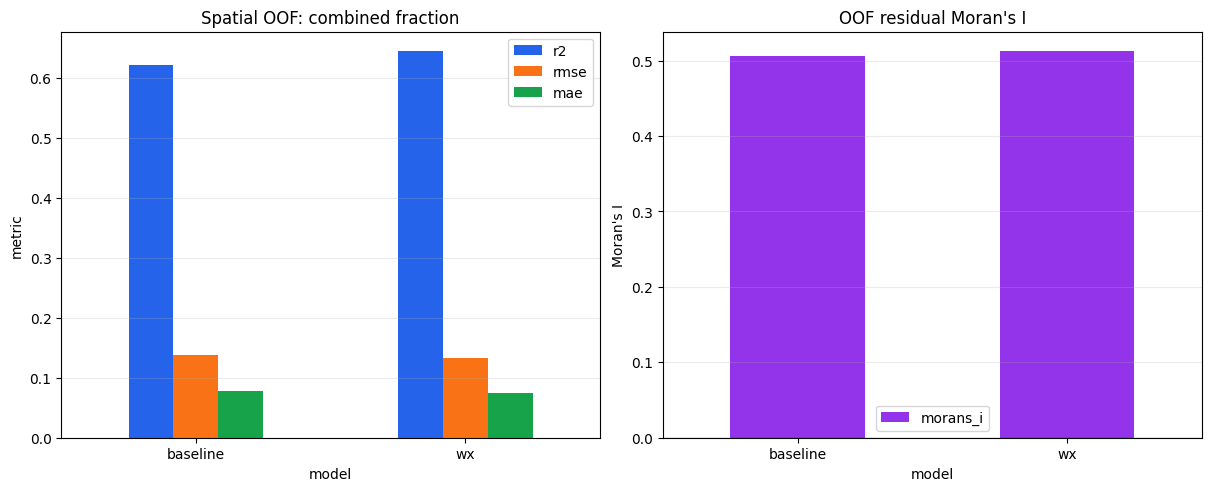

=== WX minus baseline ===
delta R2  : 0.023537291757919965
delta RMSE: -0.0043458419107458846
delta MAE : -0.002804513014119603
delta Moran: 0.006433109878860477
saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison
figure: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\spatial_wx_comparison.png


In [7]:
combined = global_metrics_df[
    (global_metrics_df["target"] == "combined_two_stage_fraction")
    & (global_metrics_df["weighting"] == "unweighted_sample")
].set_index("model")

moran_overall = moran_df[moran_df["scope"] == "overall_oof"].set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
combined[["r2", "rmse", "mae"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#2563eb", "#f97316", "#16a34a"],
)
axes[0].set_title("Spatial OOF: combined fraction")
axes[0].set_ylabel("metric")
axes[0].grid(axis="y", alpha=0.25)
axes[0].tick_params(axis="x", rotation=0)

moran_overall[["morans_i"]].plot(kind="bar", ax=axes[1], color="#9333ea")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("OOF residual Moran's I")
axes[1].set_ylabel("Moran's I")
axes[1].grid(axis="y", alpha=0.25)
axes[1].tick_params(axis="x", rotation=0)

figure_path = OUTPUT_DIR / "spatial_wx_comparison.png"
fig.savefig(figure_path, dpi=220, bbox_inches="tight")
plt.show()

print("=== WX minus baseline ===")
print("delta R2  :", float(combined.loc["wx", "r2"] - combined.loc["baseline", "r2"]))
print("delta RMSE:", float(combined.loc["wx", "rmse"] - combined.loc["baseline", "rmse"]))
print("delta MAE :", float(combined.loc["wx", "mae"] - combined.loc["baseline", "mae"]))
print("delta Moran:", float(
    moran_overall.loc["wx", "morans_i"]
    - moran_overall.loc["baseline", "morans_i"]
))
print("saved:", OUTPUT_DIR)
print("figure:", figure_path)

In [8]:
import shap

SHAP_MAX_ROWS_PER_FOLD = 10_000
SHAP_BACKGROUND_ROWS = 500
SHAP_RANDOM_SEED = RANDOM_SEED + 900
SHAP_DIR = OUTPUT_DIR / "oof_shap"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print("SHAP version:", shap.__version__)
print("SHAP output:", SHAP_DIR)


def shap_values_raw(model, frame, features):
    """LightGBMのraw outputに対するTree SHAPを返す。"""
    X = frame[features]

    try:
        explainer = shap.TreeExplainer(
            model,
            feature_perturbation="tree_path_dependent",
            model_output="raw",
        )
        values = explainer.shap_values(
            X,
            check_additivity=False,
        )
    except Exception as error:
        print("Tree SHAP with explicit settings failed; retry:", repr(error))
        explainer = shap.TreeExplainer(model)
        values = explainer.shap_values(
            X,
            check_additivity=False,
        )

    if isinstance(values, list):
        values = values[1] if len(values) == 2 else values[0]

    values = np.asarray(values)
    if values.ndim == 3:
        values = values[:, :, -1]

    if values.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {values.shape}")
    if values.shape[1] != len(features):
        raise ValueError(
            f"SHAP feature count mismatch: {values.shape} vs {len(features)}"
        )

    return values.astype(np.float32, copy=False)


def choose_shap_indices(indices, max_rows, seed):
    indices = np.asarray(indices, dtype=int)
    if max_rows is None or len(indices) <= max_rows:
        return np.sort(indices)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(indices, size=max_rows, replace=False))


def fit_models_for_shap(train_df, features, fold_number):
    """OOF本体と同じハイパーパラメータでfold内モデルを再学習する。"""
    classifier = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=4,
        verbose=-1,
    )
    classifier.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=["exclusion_class"],
    )

    positive_train = train_df[train_df["presence"].eq(1)]
    regressor = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=4,
        verbose=-1,
    )
    regressor.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=["exclusion_class"],
    )
    return classifier, regressor


def domain_group_for_feature(feature):
    """個別変数を農業経済・自然条件の概念グループへ割り当てる。"""
    token = feature.split("km_", 1)[1] if feature.startswith("wx_") else feature

    if token in {"elevation_m", "slope", "exclusion_class"}:
        return "terrain_constraints"
    if token == "log_pop_density_2024":
        return "population_labor"
    if token in {"log_city_time_20k_min", "log_port_time_any_min"}:
        return "market_access"
    if token in {"log_glofas_p10_2020", "log_distance_river_gt10_2020"}:
        return "water_resources"
    if token in {"log_rainfed_value_top5", "log_rainfed_calorie_top5"}:
        return "rainfed_potential"
    if token in {
        "log_irrigation_value_gain_top5",
        "log_irrigation_calorie_gain_top5",
    }:
        return "irrigation_potential"
    return "other"


def make_domain_groups(features):
    groups = {}
    for feature in features:
        group_name = domain_group_for_feature(feature)
        groups.setdefault(group_name, []).append(feature)
    return groups


def weighted_summary_parts(values, sample_indices):
    values = np.asarray(values, dtype=float)
    if area_weight is None:
        weights = np.ones(len(values), dtype=float)
    else:
        weights = np.asarray(area_weight[sample_indices], dtype=float)

    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return {
            "n": 0,
            "weight_sum": 0.0,
            "sum_abs_weighted": 0.0,
            "sum_signed_weighted": 0.0,
            "sum_abs_unweighted": 0.0,
            "sum_signed_unweighted": 0.0,
        }

    return {
        "n": int(len(values)),
        "weight_sum": float(weights.sum()),
        "sum_abs_weighted": float(np.sum(weights * np.abs(values))),
        "sum_signed_weighted": float(np.sum(weights * values)),
        "sum_abs_unweighted": float(np.sum(np.abs(values))),
        "sum_signed_unweighted": float(np.sum(values)),
    }


def append_shap_summary_rows(
    rows_out,
    shap_values,
    features,
    sample_indices,
    model_name,
    stage_name,
    fold_number,
):
    """個別変数と概念グループの集計用に十分統計量を保存する。"""
    for feature_index, feature in enumerate(features):
        stats = weighted_summary_parts(
            shap_values[:, feature_index],
            sample_indices,
        )
        rows_out.append({
            "model": model_name,
            "stage": stage_name,
            "fold": fold_number,
            "feature": feature,
            **stats,
        })

    for group_name, group_features in make_domain_groups(features).items():
        group_indices = [features.index(feature) for feature in group_features]
        group_signed = shap_values[:, group_indices].sum(axis=1)
        group_abs = np.abs(shap_values[:, group_indices]).sum(axis=1)
        stats_signed = weighted_summary_parts(group_signed, sample_indices)
        stats_abs = weighted_summary_parts(group_abs, sample_indices)

        rows_out.append({
            "model": model_name,
            "stage": stage_name,
            "fold": fold_number,
            "group": group_name,
            "group_features": "|".join(group_features),
            "n": stats_abs["n"],
            "weight_sum": stats_abs["weight_sum"],
            "sum_abs_weighted": stats_abs["sum_abs_weighted"],
            "sum_signed_weighted": stats_signed["sum_signed_weighted"],
            "sum_abs_unweighted": stats_abs["sum_abs_unweighted"],
            "sum_signed_unweighted": stats_abs["sum_signed_unweighted"],
        })


def finalize_shap_summary(frame, key_column):
    """fold別の十分統計量から全OOFの平均SHAPを作る。"""
    sum_columns = [
        "n",
        "weight_sum",
        "sum_abs_weighted",
        "sum_signed_weighted",
        "sum_abs_unweighted",
        "sum_signed_unweighted",
    ]
    grouped = (
        frame
        .groupby(["model", "stage", key_column], as_index=False)[sum_columns]
        .sum()
    )
    grouped["mean_abs_shap"] = (
        grouped["sum_abs_weighted"]
        / grouped["weight_sum"].replace(0, np.nan)
    )
    grouped["mean_signed_shap"] = (
        grouped["sum_signed_weighted"]
        / grouped["weight_sum"].replace(0, np.nan)
    )
    grouped["mean_abs_shap_unweighted"] = (
        grouped["sum_abs_unweighted"]
        / grouped["n"].replace(0, np.nan)
    )
    grouped["mean_signed_shap_unweighted"] = (
        grouped["sum_signed_unweighted"]
        / grouped["n"].replace(0, np.nan)
    )
    grouped["relative_importance_share"] = (
        grouped
        .groupby(["model", "stage"])["mean_abs_shap"]
        .transform(lambda values: values / values.sum())
    )
    return grouped.sort_values(
        ["model", "stage", "mean_abs_shap"],
        ascending=[True, True, False],
    )

c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0
SHAP output: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\oof_shap


In [9]:
feature_shap_rows = []
group_shap_rows = []

for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
    train_df = analysis_sample.iloc[train_idx].copy()

    print("=" * 70)
    print(f"OOF SHAP FOLD {fold_number}/{N_SPLITS}")

    for model_name, features in feature_cols_by_model.items():
        print("model:", model_name)
        classifier, regressor = fit_models_for_shap(
            train_df,
            features,
            fold_number,
        )

        test_indices_shap = choose_shap_indices(
            test_idx,
            SHAP_MAX_ROWS_PER_FOLD,
            SHAP_RANDOM_SEED + fold_number,
        )
        test_df_shap = analysis_sample.iloc[test_indices_shap].copy()

        classifier_shap = shap_values_raw(
            classifier,
            test_df_shap,
            features,
        )
        append_shap_summary_rows(
            feature_shap_rows,
            classifier_shap,
            features,
            test_indices_shap,
            model_name,
            "presence_classifier",
            fold_number,
        )
        append_shap_summary_rows(
            group_shap_rows,
            classifier_shap,
            features,
            test_indices_shap,
            model_name,
            "presence_classifier",
            fold_number,
        )

        positive_test_indices = test_idx[y_all[test_idx] == 1]
        positive_test_indices_shap = choose_shap_indices(
            positive_test_indices,
            SHAP_MAX_ROWS_PER_FOLD,
            SHAP_RANDOM_SEED + 1000 + fold_number,
        )
        positive_test_df_shap = analysis_sample.iloc[
            positive_test_indices_shap
        ].copy()

        if len(positive_test_indices_shap) > 0:
            regressor_shap = shap_values_raw(
                regressor,
                positive_test_df_shap,
                features,
            )
            append_shap_summary_rows(
                feature_shap_rows,
                regressor_shap,
                features,
                positive_test_indices_shap,
                model_name,
                "conditional_fraction_regressor",
                fold_number,
            )
            append_shap_summary_rows(
                group_shap_rows,
                regressor_shap,
                features,
                positive_test_indices_shap,
                model_name,
                "conditional_fraction_regressor",
                fold_number,
            )

        del classifier, regressor, classifier_shap
        if "regressor_shap" in locals():
            del regressor_shap
        gc.collect()

feature_shap_fold = pd.DataFrame(feature_shap_rows)
group_shap_fold = pd.DataFrame(group_shap_rows)

feature_shap_summary = finalize_shap_summary(feature_shap_fold, "feature")
group_shap_summary = finalize_shap_summary(group_shap_fold, "group")

feature_shap_summary.to_csv(
    SHAP_DIR / "spatial_wx_feature_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
group_shap_summary.to_csv(
    SHAP_DIR / "spatial_wx_group_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
feature_shap_fold.to_csv(
    SHAP_DIR / "spatial_wx_feature_shap_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
group_shap_fold.to_csv(
    SHAP_DIR / "spatial_wx_group_shap_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=== Group SHAP: top results ===")
print(
    group_shap_summary[
        [
            "model",
            "stage",
            "group",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ]
    .round(5)
    .to_string(index=False)
)

print("=== Individual feature SHAP: top results ===")
print(
    feature_shap_summary[
        [
            "model",
            "stage",
            "feature",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ]
    .round(5)
    .to_string(index=False)
)

OOF SHAP FOLD 1/5
model: baseline


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


model: wx


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


OOF SHAP FOLD 2/5
model: baseline


...

OOF SHAP FOLD 5/5
model: baseline


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


model: wx


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


=== Group SHAP: top results ===
   model                          stage                group  mean_abs_shap  mean_signed_shap  relative_importance_share
baseline conditional_fraction_regressor  terrain_constraints        0.10264          -0.00430                    0.33658
baseline conditional_fraction_regressor     population_labor        0.06324          -0.00036                    0.20737
baseline conditional_fraction_regressor        market_access        0.04975           0.00010                    0.16313
baseline conditional_fraction_regressor    rainfed_potential        0.04545          -0.00635                    0.14903
baseline conditional_fraction_regressor irrigation_potential        0.02869          -0.00103                    0.09407
baseline conditional_fraction_regressor      water_resources        0.01519          -0.00200                    0.04982
baseline            presence_classifier        market_access        1.91034           0.19935                    0.37719


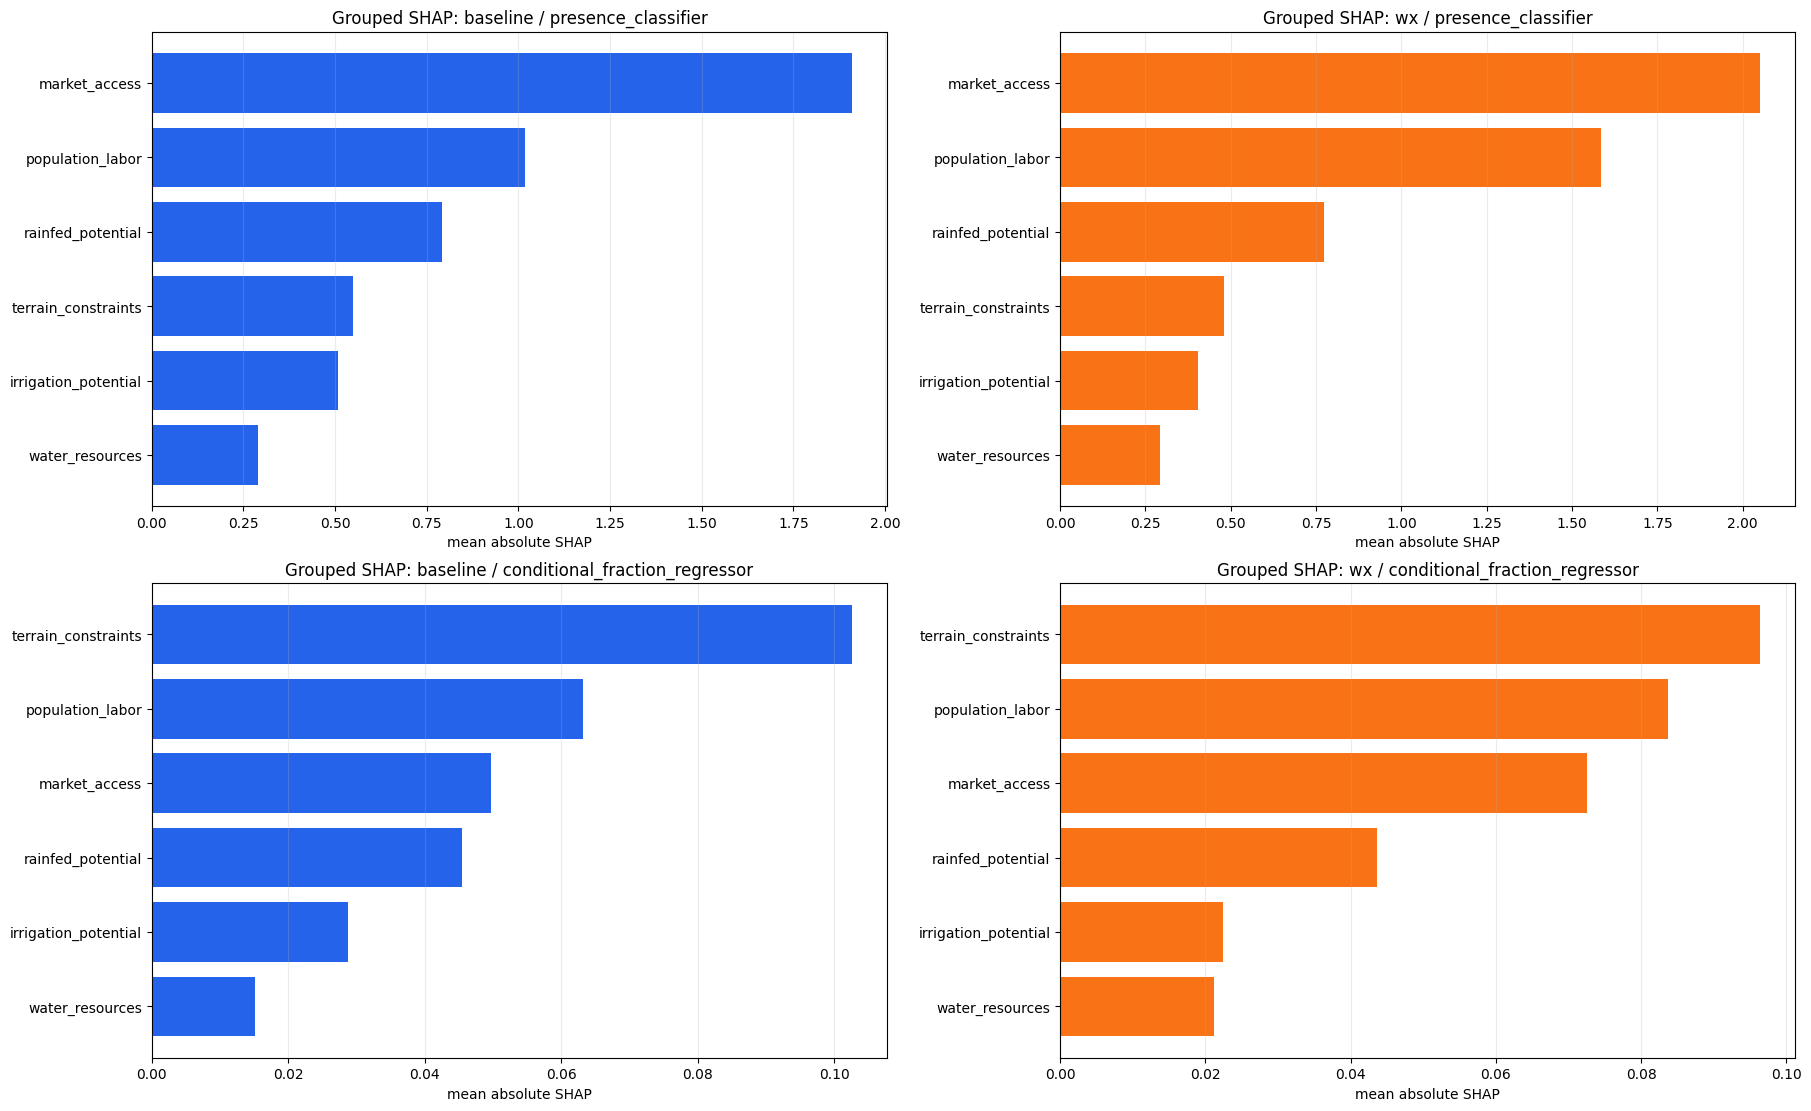

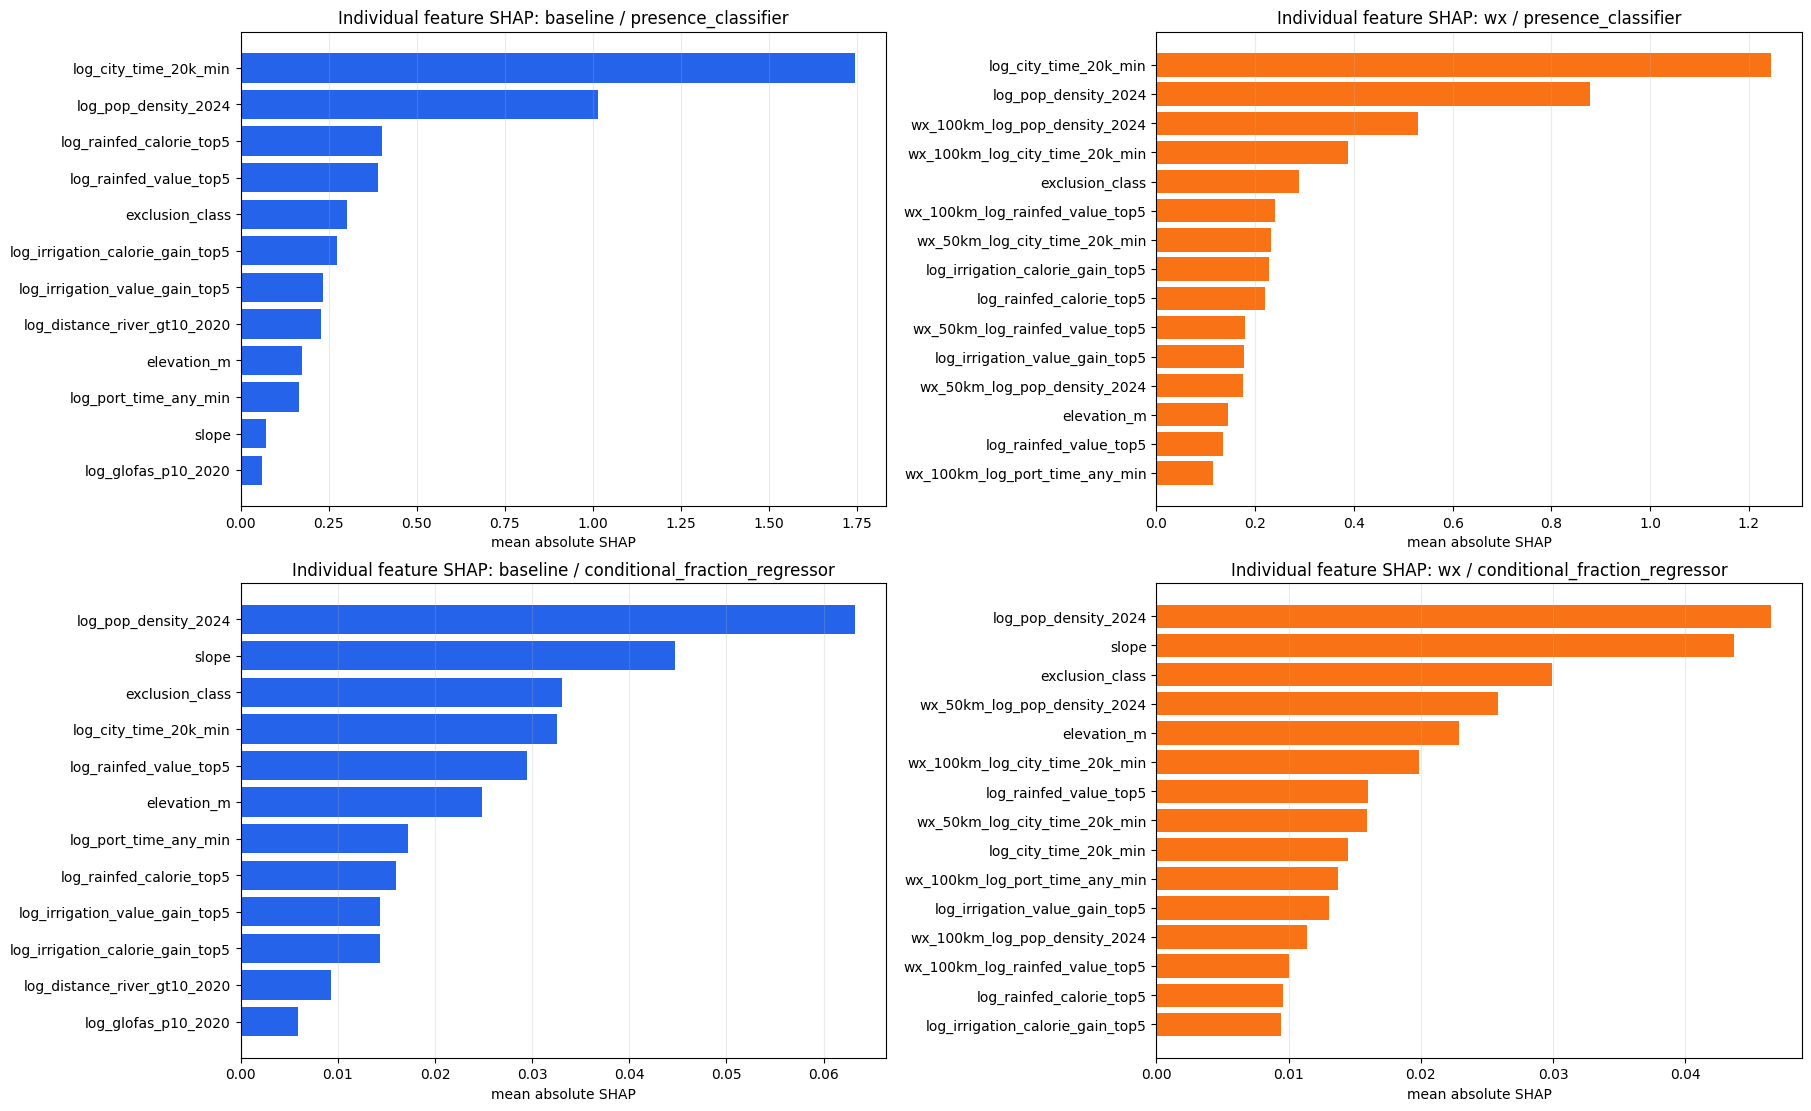

Group figure: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\oof_shap\spatial_wx_group_shap.png
Feature figure: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\oof_shap\spatial_wx_individual_feature_shap.png


In [10]:
def plot_shap_bars(summary_df, key_column, title_prefix, output_name, top_n=None):
    models = ["baseline", "wx"]
    stages = [
        "presence_classifier",
        "conditional_fraction_regressor",
    ]

    fig, axes = plt.subplots(
        len(stages),
        len(models),
        figsize=(18, 11),
        squeeze=False,
        constrained_layout=True,
    )

    for row_index, stage_name in enumerate(stages):
        for col_index, model_name in enumerate(models):
            ax = axes[row_index, col_index]
            plot_df = summary_df[
                (summary_df["model"] == model_name)
                & (summary_df["stage"] == stage_name)
            ].copy()

            if plot_df.empty:
                ax.set_visible(False)
                continue

            plot_df = plot_df.sort_values("mean_abs_shap", ascending=True)
            if top_n is not None:
                plot_df = plot_df.tail(top_n)

            labels = plot_df[key_column].astype(str)
            ax.barh(
                labels,
                plot_df["mean_abs_shap"],
                color="#2563eb" if model_name == "baseline" else "#f97316",
            )
            ax.set_title(f"{title_prefix}: {model_name} / {stage_name}")
            ax.set_xlabel("mean absolute SHAP")
            ax.grid(axis="x", alpha=0.25)

    figure_path = SHAP_DIR / output_name
    fig.savefig(figure_path, dpi=220, bbox_inches="tight")
    plt.show()
    return figure_path


group_figure_path = plot_shap_bars(
    group_shap_summary,
    key_column="group",
    title_prefix="Grouped SHAP",
    output_name="spatial_wx_group_shap.png",
    top_n=None,
)

feature_figure_path = plot_shap_bars(
    feature_shap_summary,
    key_column="feature",
    title_prefix="Individual feature SHAP",
    output_name="spatial_wx_individual_feature_shap.png",
    top_n=15,
)

print("Group figure:", group_figure_path)
print("Feature figure:", feature_figure_path)

## 【セル20】raw_crop / raw_crop_wxの再推定（復元セル）

次のコードセル（セル21）で、crop-potentialをraw値・存在フラグ等に変更した5-fold Spatial OOFを実行します。セル14–19の旧SHAPは実行せず、セル21を実行してください。

In [11]:
# ============================================================
# 追加セル
# Crop potentialをraw値＋存在フラグで再学習
# raw_crop と raw_crop_wx を既存モデルと比較
# ============================================================

print("=" * 70)
print("RAW CROP-POTENTIAL RE-ESTIMATION")
print("=" * 70)

required_objects = [
    "analysis_sample",
    "splits",
    "fit_predict_two_stage",
    "regression_summary",
    "classification_summary",
    "feature_cols_by_model",
    "wx_feature_cols",
    "base_feature_cols",
    "area_weight",
    "weight_specs",
]

missing = [
    name for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"以下の変数がありません: {missing}\n"
        "先にセル1〜12を実行してください。"
    )


# ------------------------------------------------------------
# 1. 既存のanalysis_sampleをコピー
# ------------------------------------------------------------

raw_analysis_sample = analysis_sample.copy()

raw_rows = raw_analysis_sample["row"].to_numpy(dtype=int)
raw_cols = raw_analysis_sample["col"].to_numpy(dtype=int)


def sample_raster(array):
    return np.asarray(
        array[raw_rows, raw_cols],
        dtype=np.float32,
    )


def clean_positive_feature(values):
    """
    正の値だけをraw値として残す。
    非正値は0にする。
    同時に、存在フラグと欠測フラグも返す。
    """
    values = np.asarray(values, dtype=np.float32)

    finite = np.isfinite(values)
    exists = finite & (values > 0)
    missing = ~finite

    clean = np.where(
        exists,
        values,
        0.0,
    ).astype(np.float32)

    return (
        clean,
        exists.astype(np.uint8),
        missing.astype(np.uint8),
    )


# ------------------------------------------------------------
# 2. crop potentialのraw値を作成
# ------------------------------------------------------------

rainfed_value_sample = sample_raster(rainfed_value_top5)
irrigated_value_sample = sample_raster(irrigated_value_top5)

rainfed_calorie_sample = sample_raster(rainfed_calorie_top5)
irrigated_calorie_sample = sample_raster(irrigated_calorie_top5)


(
    rainfed_value_raw,
    rainfed_value_exists,
    rainfed_value_missing,
) = clean_positive_feature(rainfed_value_sample)

(
    rainfed_calorie_raw,
    rainfed_calorie_exists,
    rainfed_calorie_missing,
) = clean_positive_feature(rainfed_calorie_sample)


# ------------------------------------------------------------
# 3. 灌漑gainと符号付き差分を作成
# ------------------------------------------------------------

value_pair_valid = (
    np.isfinite(rainfed_value_sample)
    & np.isfinite(irrigated_value_sample)
)

calorie_pair_valid = (
    np.isfinite(rainfed_calorie_sample)
    & np.isfinite(irrigated_calorie_sample)
)


# 符号付き差分
irrigation_value_delta_signed = np.where(
    value_pair_valid,
    irrigated_value_sample - rainfed_value_sample,
    0.0,
).astype(np.float32)

irrigation_calorie_delta_signed = np.where(
    calorie_pair_valid,
    irrigated_calorie_sample - rainfed_calorie_sample,
    0.0,
).astype(np.float32)


# 非負gain
irrigation_value_gain_raw = np.maximum(
    irrigation_value_delta_signed,
    0.0,
).astype(np.float32)

irrigation_calorie_gain_raw = np.maximum(
    irrigation_calorie_delta_signed,
    0.0,
).astype(np.float32)


# gainの存在フラグ
irrigation_value_gain_exists = (
    value_pair_valid
    & (irrigation_value_delta_signed > 0)
).astype(np.uint8)

irrigation_calorie_gain_exists = (
    calorie_pair_valid
    & (irrigation_calorie_delta_signed > 0)
).astype(np.uint8)


# 欠測フラグ
irrigation_value_gain_missing = (
    ~value_pair_valid
).astype(np.uint8)

irrigation_calorie_gain_missing = (
    ~calorie_pair_valid
).astype(np.uint8)


# ------------------------------------------------------------
# 4. DataFrameに追加
# ------------------------------------------------------------

raw_analysis_sample[
    "rainfed_value_top5_raw"
] = rainfed_value_raw

raw_analysis_sample[
    "rainfed_calorie_top5_raw"
] = rainfed_calorie_raw

raw_analysis_sample[
    "irrigation_value_gain_top5_raw"
] = irrigation_value_gain_raw

raw_analysis_sample[
    "irrigation_calorie_gain_top5_raw"
] = irrigation_calorie_gain_raw


raw_analysis_sample[
    "rainfed_value_top5_exists"
] = rainfed_value_exists

raw_analysis_sample[
    "rainfed_calorie_top5_exists"
] = rainfed_calorie_exists

raw_analysis_sample[
    "irrigation_value_gain_top5_exists"
] = irrigation_value_gain_exists

raw_analysis_sample[
    "irrigation_calorie_gain_top5_exists"
] = irrigation_calorie_gain_exists


raw_analysis_sample[
    "irrigation_value_delta_top5_signed"
] = irrigation_value_delta_signed

raw_analysis_sample[
    "irrigation_calorie_delta_top5_signed"
] = irrigation_calorie_delta_signed


raw_analysis_sample[
    "rainfed_value_top5_missing"
] = rainfed_value_missing

raw_analysis_sample[
    "rainfed_calorie_top5_missing"
] = rainfed_calorie_missing

raw_analysis_sample[
    "irrigation_value_gain_top5_missing"
] = irrigation_value_gain_missing

raw_analysis_sample[
    "irrigation_calorie_gain_top5_missing"
] = irrigation_calorie_gain_missing


# ------------------------------------------------------------
# 5. 新しいcrop potential feature list
# ------------------------------------------------------------

non_crop_base_cols = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_pop_density_2024",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_min",
]

# 実際の列名を確認
if "log_distance_river_gt10_min" not in raw_analysis_sample.columns:
    non_crop_base_cols[-1] = "log_distance_river_gt10_2020"


raw_crop_cols = [
    # rawの大きさ
    "rainfed_value_top5_raw",
    "rainfed_calorie_top5_raw",
    "irrigation_value_gain_top5_raw",
    "irrigation_calorie_gain_top5_raw",

    # 0か正値か
    "rainfed_value_top5_exists",
    "rainfed_calorie_top5_exists",
    "irrigation_value_gain_top5_exists",
    "irrigation_calorie_gain_top5_exists",

    # 灌漑による符号付き差分
    "irrigation_value_delta_top5_signed",
    "irrigation_calorie_delta_top5_signed",

    # 欠測フラグ
    "rainfed_value_top5_missing",
    "rainfed_calorie_top5_missing",
    "irrigation_value_gain_top5_missing",
    "irrigation_calorie_gain_top5_missing",
]


raw_crop_feature_cols = (
    non_crop_base_cols
    + raw_crop_cols
)


# ------------------------------------------------------------
# 6. raw版のcrop potential WXを作る
# ------------------------------------------------------------

raw_rainfed_value_raster = np.asarray(
    rainfed_value_top5,
    dtype=np.float32,
)

raw_rainfed_value_valid = np.isfinite(
    raw_rainfed_value_raster
)

raw_rainfed_value_clean_raster = np.where(
    raw_rainfed_value_valid
    & (raw_rainfed_value_raster > 0),
    raw_rainfed_value_raster,
    0.0,
).astype(np.float32)

raw_rainfed_value_exists_raster = (
    raw_rainfed_value_valid
    & (raw_rainfed_value_raster > 0)
).astype(np.float32)


raw_crop_wx_feature_cols = []

for radius_km in WX_RADII_KM:

    raw_wx_specs = [
        (
            f"wx_{radius_km}km_rainfed_value_top5_raw",
            raw_rainfed_value_clean_raster,
        ),
        (
            f"wx_{radius_km}km_rainfed_value_exists_share",
            raw_rainfed_value_exists_raster,
        ),
    ]

    for wx_name, source_values in raw_wx_specs:

        cache_path = (
            OUTPUT_DIR
            / f"{wx_name}.npy"
        )

        if cache_path.exists():
            print("load raw WX cache:", cache_path.name)
            wx_raster = np.load(
                cache_path,
                mmap_mode="r",
            )
        else:
            print("build raw WX:", wx_name)

            wx_raster = latitude_aware_box_mean(
                source_values,
                lat,
                radius_km,
                min_valid_fraction=MIN_VALID_NEIGHBOR_FRACTION,
            )

            if SAVE_WX_RASTERS:
                np.save(
                    cache_path,
                    wx_raster.astype(
                        np.float32,
                        copy=False,
                    ),
                )

        raw_analysis_sample[wx_name] = np.asarray(
            wx_raster[raw_rows, raw_cols],
            dtype=np.float32,
        )

        raw_crop_wx_feature_cols.append(wx_name)


# 既存WXから、log版rainfed value WXだけ除外
non_crop_wx_feature_cols = [
    col
    for col in wx_feature_cols
    if "log_rainfed_value_top5" not in col
]


raw_crop_wx_feature_cols = (
    raw_crop_feature_cols
    + non_crop_wx_feature_cols
    + raw_crop_wx_feature_cols
)


feature_cols_raw_by_model = {
    "raw_crop": raw_crop_feature_cols,
    "raw_crop_wx": raw_crop_wx_feature_cols,
}


print()
print("raw_crop feature count:", len(raw_crop_feature_cols))
print("raw_crop_wx feature count:", len(raw_crop_wx_feature_cols))
print()
print("raw_crop features:")
print(raw_crop_feature_cols)
print()
print("raw_crop_wx features:")
print(raw_crop_wx_feature_cols)


# ------------------------------------------------------------
# 7. raw版Spatial OOF
# ------------------------------------------------------------

raw_oof = {
    model_name: {
        "fold": np.full(
            len(raw_analysis_sample),
            -1,
            dtype=np.int16,
        ),
        "presence_raw": np.full(
            len(raw_analysis_sample),
            np.nan,
            dtype=np.float32,
        ),
        "presence_calibrated": np.full(
            len(raw_analysis_sample),
            np.nan,
            dtype=np.float32,
        ),
        "fraction_conditional": np.full(
            len(raw_analysis_sample),
            np.nan,
            dtype=np.float32,
        ),
        "fraction_expected": np.full(
            len(raw_analysis_sample),
            np.nan,
            dtype=np.float32,
        ),
    }
    for model_name in feature_cols_raw_by_model
}


raw_fold_rows = []

for fold_number, (train_idx, test_idx) in enumerate(
    splits,
    start=1,
):

    train_df = raw_analysis_sample.iloc[train_idx]
    test_df = raw_analysis_sample.iloc[test_idx]

    print()
    print("=" * 70)
    print(
        f"RAW MODEL FOLD {fold_number}/{N_SPLITS}"
    )
    print("=" * 70)

    for model_name, features in feature_cols_raw_by_model.items():

        print(
            f"training: {model_name} "
            f"({len(features)} features)"
        )

        raw_probability, calibrated_probability, conditional, expected = (
            fit_predict_two_stage(
                train_df,
                test_df,
                features,
                fold_number,
            )
        )

        raw_oof[model_name]["fold"][test_idx] = (
            fold_number
        )

        raw_oof[model_name]["presence_raw"][test_idx] = (
            raw_probability
        )

        raw_oof[model_name]["presence_calibrated"][test_idx] = (
            calibrated_probability
        )

        raw_oof[model_name]["fraction_conditional"][test_idx] = (
            conditional
        )

        raw_oof[model_name]["fraction_expected"][test_idx] = (
            expected
        )

        y_test = test_df[
            "presence"
        ].to_numpy(dtype=np.uint8)

        y_fraction = test_df[
            "cropland_fraction"
        ].to_numpy(dtype=float)

        positive_mask = y_test == 1

        combined_metrics = regression_summary(
            y_fraction,
            expected,
        )

        conditional_metrics = regression_summary(
            y_fraction[positive_mask],
            conditional[positive_mask],
        )

        stage1_metrics = classification_summary(
            y_test,
            raw_probability,
        )

        raw_fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "presence_auc": stage1_metrics["auc"],
            "presence_average_precision": (
                stage1_metrics["average_precision"]
            ),
            "combined_r2": combined_metrics["r2"],
            "combined_rmse": combined_metrics["rmse"],
            "combined_mae": combined_metrics["mae"],
            "conditional_r2": conditional_metrics["r2"],
            "conditional_rmse": conditional_metrics["rmse"],
            "conditional_mae": conditional_metrics["mae"],
        })

        del (
            raw_probability,
            calibrated_probability,
            conditional,
            expected,
        )

        gc.collect()


raw_fold_metrics_df = pd.DataFrame(
    raw_fold_rows
)


# ------------------------------------------------------------
# 8. raw版のOOF予測テーブル
# ------------------------------------------------------------

raw_oof_table = raw_analysis_sample[
    [
        "row",
        "col",
        "lat",
        "lon",
        "spatial_block",
        "presence",
        "cropland_fraction",
    ]
].copy()


for model_name, values in raw_oof.items():

    raw_oof_table[
        f"{model_name}_presence_probability_raw"
    ] = values["presence_raw"]

    raw_oof_table[
        f"{model_name}_presence_probability_calibrated"
    ] = values["presence_calibrated"]

    raw_oof_table[
        f"{model_name}_fraction_positive_conditional"
    ] = values["fraction_conditional"]

    raw_oof_table[
        f"{model_name}_fraction_expected_oof"
    ] = values["fraction_expected"]

    raw_oof_table[
        f"{model_name}_residual"
    ] = (
        raw_oof_table["cropland_fraction"]
        - raw_oof_table[
            f"{model_name}_fraction_expected_oof"
        ]
    )


# ------------------------------------------------------------
# 9. raw版の全球OOF評価
# ------------------------------------------------------------

raw_global_rows = []

for model_name, values in raw_oof.items():

    for weighting, weights in weight_specs.items():

        combined_metrics = regression_summary(
            raw_oof_table[
                "cropland_fraction"
            ].to_numpy(dtype=float),
            values["fraction_expected"],
            weights=weights,
        )

        raw_global_rows.append({
            "model": model_name,
            "target": "combined_two_stage_fraction",
            "weighting": weighting,
            **combined_metrics,
        })

        positive_mask = (
            raw_oof_table["presence"].to_numpy()
            == 1
        )

        conditional_metrics = regression_summary(
            raw_oof_table.loc[
                positive_mask,
                "cropland_fraction",
            ].to_numpy(dtype=float),
            values["fraction_conditional"][
                positive_mask
            ],
            weights=(
                None
                if weights is None
                else weights[positive_mask]
            ),
        )

        raw_global_rows.append({
            "model": model_name,
            "target": "positive_conditional_fraction",
            "weighting": weighting,
            **conditional_metrics,
        })

        stage1_metrics = classification_summary(
            raw_oof_table["presence"].to_numpy(dtype=np.uint8),
            values["presence_raw"],
            weights=weights,
        )

        raw_global_rows.append({
            "model": model_name,
            "target": "presence",
            "weighting": weighting,
            **stage1_metrics,
        })


raw_global_metrics_df = pd.DataFrame(
    raw_global_rows
)


# ------------------------------------------------------------
# 10. Moran's I
# ------------------------------------------------------------

raw_moran_indices = np.arange(
    len(raw_oof_table)
)

if len(raw_moran_indices) > MORAN_MAX_N:
    rng_raw_moran = np.random.default_rng(
        RANDOM_SEED + 1700
    )

    raw_moran_indices = rng_raw_moran.choice(
        raw_moran_indices,
        MORAN_MAX_N,
        replace=False,
    )


raw_moran_rows = []

for model_name in raw_oof:

    overall = morans_i_knn(
        raw_oof_table,
        raw_oof_table[
            f"{model_name}_residual"
        ].to_numpy(dtype=float),
        k=MORAN_K,
        selected_indices=raw_moran_indices,
    )

    raw_moran_rows.append({
        "scope": "overall_oof",
        "model": model_name,
        **overall,
    })

    for fold_number in range(1, N_SPLITS + 1):

        fold_indices = np.flatnonzero(
            raw_oof[model_name]["fold"]
            == fold_number
        )

        if len(fold_indices) <= MORAN_K + 1:
            continue

        fold_frame = (
            raw_oof_table
            .iloc[fold_indices]
            .reset_index(drop=True)
        )

        fold_residual = raw_oof_table.iloc[
            fold_indices
        ][
            f"{model_name}_residual"
        ].to_numpy(dtype=float)

        fold_result = morans_i_knn(
            fold_frame,
            fold_residual,
            k=MORAN_K,
        )

        raw_moran_rows.append({
            "scope": "oof_fold",
            "model": model_name,
            "fold": fold_number,
            **fold_result,
        })


raw_moran_df = pd.DataFrame(
    raw_moran_rows
)


# ------------------------------------------------------------
# 11. 保存
# ------------------------------------------------------------

raw_global_metrics_df.to_csv(
    OUTPUT_DIR
    / "spatial_wx_raw_crop_global_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

raw_fold_metrics_df.to_csv(
    OUTPUT_DIR
    / "spatial_wx_raw_crop_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

raw_oof_table.to_csv(
    OUTPUT_DIR
    / "spatial_wx_raw_crop_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

raw_moran_df.to_csv(
    OUTPUT_DIR
    / "spatial_wx_raw_crop_morans_i.csv",
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# 12. 既存モデルとの比較表示
# ------------------------------------------------------------

print()
print("=" * 70)
print("EXISTING VS RAW CROP-POTENTIAL MODELS")
print("=" * 70)

old_combined = global_metrics_df[
    (global_metrics_df["target"]
     == "combined_two_stage_fraction")
    & (global_metrics_df["weighting"]
       == "unweighted_sample")
].copy()

new_combined = raw_global_metrics_df[
    (raw_global_metrics_df["target"]
     == "combined_two_stage_fraction")
    & (raw_global_metrics_df["weighting"]
       == "unweighted_sample")
].copy()

comparison = pd.concat(
    [
        old_combined,
        new_combined,
    ],
    ignore_index=True,
)

print(
    comparison[
        [
            "model",
            "r2",
            "rmse",
            "mae",
            "bias_observed_minus_predicted",
        ]
    ].round(5).to_string(index=False)
)


print()
print("=== Existing Moran's I ===")

if "moran_df" in globals():
    print(
        moran_df[
            moran_df["scope"] == "overall_oof"
        ][
            [
                "model",
                "morans_i",
                "expected_i",
                "n",
                "k",
            ]
        ].round(5).to_string(index=False)
    )


print()
print("=== Raw crop Moran's I ===")

print(
    raw_moran_df[
        raw_moran_df["scope"] == "overall_oof"
    ][
        [
            "model",
            "morans_i",
            "expected_i",
            "n",
            "k",
        ]
    ].round(5).to_string(index=False)
)


print()
print("保存先:")
print(
    OUTPUT_DIR
    / "spatial_wx_raw_crop_global_metrics.csv"
)
print(
    OUTPUT_DIR
    / "spatial_wx_raw_crop_fold_metrics.csv"
)
print(
    OUTPUT_DIR
    / "spatial_wx_raw_crop_oof_predictions.csv"
)
print(
    OUTPUT_DIR
    / "spatial_wx_raw_crop_morans_i.csv"
)

RAW CROP-POTENTIAL RE-ESTIMATION
load raw WX cache: wx_50km_rainfed_value_top5_raw.npy
load raw WX cache: wx_50km_rainfed_value_exists_share.npy
load raw WX cache: wx_100km_rainfed_value_top5_raw.npy
load raw WX cache: wx_100km_rainfed_value_exists_share.npy

raw_crop feature count: 22
raw_crop_wx feature count: 36

raw_crop features:
['elevation_m', 'slope', 'exclusion_class', 'log_pop_density_2024', 'log_city_time_20k_min', 'log_port_time_any_min', 'log_glofas_p10_2020', 'log_distance_river_gt10_2020', 'rainfed_value_top5_raw', 'rainfed_calorie_top5_raw', 'irrigation_value_gain_top5_raw', 'irrigation_calorie_gain_top5_raw', 'rainfed_value_top5_exists', 'rainfed_calorie_top5_exists', 'irrigation_value_gain_top5_exists', 'irrigation_calorie_gain_top5_exists', 'irrigation_value_delta_top5_signed', 'irrigation_calorie_delta_top5_signed', 'rainfed_value_top5_missing', 'rainfed_calorie_top5_missing', 'irrigation_value_gain_top5_missing', 'irrigation_calorie_gain_top5_missing']

raw_crop_wx

## 【セル22】GLOBAL R²・面積加重R²・fold別比較（復元セル）

セル21の実行後に、次のコードセル（セル23）を実行します。baseline、WX、raw_crop、raw_crop_wxを同じ条件で比較し、raw_crop_wxが最良かを確認します。

In [12]:
# ============================================================
# Area-weighted R² と fold別R²の比較
# ============================================================

print("=" * 70)
print("AREA-WEIGHTED AND FOLD-BY-FOLD R² COMPARISON")
print("=" * 70)


if area_weight is None:
    raise RuntimeError(
        "area_weight がありません。grid_area_km2.npyを確認してください。"
    )


def weighted_regression_metrics(
    y_true,
    y_pred,
    weights=None,
):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
        & np.isfinite(weights)
        & (weights > 0)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]
    weights = weights[valid]

    weighted_mean = np.average(
        y_true,
        weights=weights,
    )

    residual = y_true - y_pred

    ss_res = np.sum(
        weights * residual**2
    )

    ss_tot = np.sum(
        weights * (y_true - weighted_mean)**2
    )

    r2 = (
        1.0 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    rmse = np.sqrt(
        np.average(
            residual**2,
            weights=weights,
        )
    )

    mae = np.average(
        np.abs(residual),
        weights=weights,
    )

    return {
        "n": len(y_true),
        "r2": float(r2),
        "rmse": float(rmse),
        "mae": float(mae),
        "observed_mean": float(weighted_mean),
        "predicted_mean": float(
            np.average(y_pred, weights=weights)
        ),
    }


# ------------------------------------------------------------
# モデルとOOF結果
# ------------------------------------------------------------

model_values = {
    "baseline": oof["baseline"],
    "wx": oof["wx"],
    "raw_crop": raw_oof["raw_crop"],
    "raw_crop_wx": raw_oof["raw_crop_wx"],
}

y_all_r2 = analysis_sample[
    "cropland_fraction"
].to_numpy(dtype=float)

fold_values = {
    name: values["fold"]
    for name, values in model_values.items()
}


# ------------------------------------------------------------
# 1. 全球R²
# ------------------------------------------------------------

weighting_specs = {
    "unweighted_sample": None,
    "area_weighted_reweighted": area_weight,
}

global_r2_rows = []

for model_name, values in model_values.items():

    prediction = values[
        "fraction_expected"
    ]

    for weighting_name, weights in weighting_specs.items():

        result = weighted_regression_metrics(
            y_all_r2,
            prediction,
            weights=weights,
        )

        global_r2_rows.append({
            "model": model_name,
            "weighting": weighting_name,
            **result,
        })


global_r2_df = pd.DataFrame(
    global_r2_rows
)

print()
print("=" * 70)
print("GLOBAL R²")
print("=" * 70)

print(
    global_r2_df[
        [
            "model",
            "weighting",
            "r2",
            "rmse",
            "mae",
            "observed_mean",
            "predicted_mean",
        ]
    ].round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 2. 全球R²の改善幅
# ------------------------------------------------------------

global_r2_wide = global_r2_df.pivot(
    index="weighting",
    columns="model",
    values="r2",
).reset_index()

global_r2_wide[
    "delta_raw_crop_minus_baseline"
] = (
    global_r2_wide["raw_crop"]
    - global_r2_wide["baseline"]
)

global_r2_wide[
    "delta_raw_crop_wx_minus_wx"
] = (
    global_r2_wide["raw_crop_wx"]
    - global_r2_wide["wx"]
)

print()
print("=" * 70)
print("GLOBAL R² IMPROVEMENT")
print("=" * 70)

print(
    global_r2_wide.round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 3. Fold別R²
# ------------------------------------------------------------

fold_r2_rows = []

for model_name, values in model_values.items():

    prediction = values[
        "fraction_expected"
    ]

    fold_ids = values["fold"]

    for fold_number in range(1, N_SPLITS + 1):

        test_mask = fold_ids == fold_number

        y_fold = y_all_r2[test_mask]
        pred_fold = prediction[test_mask]

        for weighting_name, weights in weighting_specs.items():

            if weights is None:
                fold_weights = None
            else:
                fold_weights = weights[test_mask]

            result = weighted_regression_metrics(
                y_fold,
                pred_fold,
                weights=fold_weights,
            )

            fold_r2_rows.append({
                "model": model_name,
                "fold": fold_number,
                "weighting": weighting_name,
                **result,
            })


fold_r2_df = pd.DataFrame(
    fold_r2_rows
)

print()
print("=" * 70)
print("FOLD-BY-FOLD R²")
print("=" * 70)

print(
    fold_r2_df[
        [
            "model",
            "fold",
            "weighting",
            "r2",
            "rmse",
            "mae",
        ]
    ].round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 4. Fold別の改善幅
# ------------------------------------------------------------

fold_r2_wide = fold_r2_df.pivot_table(
    index=["fold", "weighting"],
    columns="model",
    values="r2",
).reset_index()

fold_r2_wide[
    "delta_raw_crop_minus_baseline"
] = (
    fold_r2_wide["raw_crop"]
    - fold_r2_wide["baseline"]
)

fold_r2_wide[
    "delta_raw_crop_wx_minus_wx"
] = (
    fold_r2_wide["raw_crop_wx"]
    - fold_r2_wide["wx"]
)

print()
print("=" * 70)
print("FOLD-BY-FOLD R² IMPROVEMENT")
print("=" * 70)

print(
    fold_r2_wide.round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 5. Fold平均と標準偏差
# ------------------------------------------------------------

fold_summary_df = (
    fold_r2_df
    .groupby(
        ["model", "weighting"],
        as_index=False,
    )
    .agg(
        mean_r2=("r2", "mean"),
        sd_r2=("r2", "std"),
        min_r2=("r2", "min"),
        max_r2=("r2", "max"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
    )
)

print()
print("=" * 70)
print("FOLD-MEAN R² SUMMARY")
print("=" * 70)

print(
    fold_summary_df.round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 6. 保存
# ------------------------------------------------------------

global_r2_df.to_csv(
    OUTPUT_DIR / "area_weighted_global_r2_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

global_r2_wide.to_csv(
    OUTPUT_DIR / "area_weighted_global_r2_delta.csv",
    index=False,
    encoding="utf-8-sig",
)

fold_r2_df.to_csv(
    OUTPUT_DIR / "area_weighted_fold_r2.csv",
    index=False,
    encoding="utf-8-sig",
)

fold_r2_wide.to_csv(
    OUTPUT_DIR / "area_weighted_fold_r2_delta.csv",
    index=False,
    encoding="utf-8-sig",
)

fold_summary_df.to_csv(
    OUTPUT_DIR / "area_weighted_fold_r2_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print()
print("保存完了:")
print(OUTPUT_DIR / "area_weighted_global_r2_comparison.csv")
print(OUTPUT_DIR / "area_weighted_global_r2_delta.csv")
print(OUTPUT_DIR / "area_weighted_fold_r2.csv")
print(OUTPUT_DIR / "area_weighted_fold_r2_delta.csv")
print(OUTPUT_DIR / "area_weighted_fold_r2_summary.csv")

AREA-WEIGHTED AND FOLD-BY-FOLD R² COMPARISON

GLOBAL R²
      model                weighting       r2     rmse      mae  observed_mean  predicted_mean
   baseline        unweighted_sample 0.621046 0.137730 0.077057       0.140451        0.126401
   baseline area_weighted_reweighted 0.616941 0.130678 0.070636       0.117253        0.111979
         wx        unweighted_sample 0.644584 0.133384 0.074253       0.140451        0.127746
         wx area_weighted_reweighted 0.644491 0.125891 0.067559       0.117253        0.112569
   raw_crop        unweighted_sample 0.625383 0.136939 0.076626       0.140451        0.126285
   raw_crop area_weighted_reweighted 0.621882 0.129832 0.070107       0.117253        0.111827
raw_crop_wx        unweighted_sample 0.646858 0.132956 0.073977       0.140451        0.127655
raw_crop_wx area_weighted_reweighted 0.646449 0.125544 0.067298       0.117253        0.112503

GLOBAL R² IMPROVEMENT
               weighting  baseline  raw_crop  raw_crop_wx       wx

## shap分析

SHAP model: raw_crop_wx
feature count: 36
output: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\oof_shap_raw_crop_wx
RAW_CROP_WX SHAP FOLD 1/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


RAW_CROP_WX SHAP FOLD 2/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


RAW_CROP_WX SHAP FOLD 3/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


RAW_CROP_WX SHAP FOLD 4/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


RAW_CROP_WX SHAP FOLD 5/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


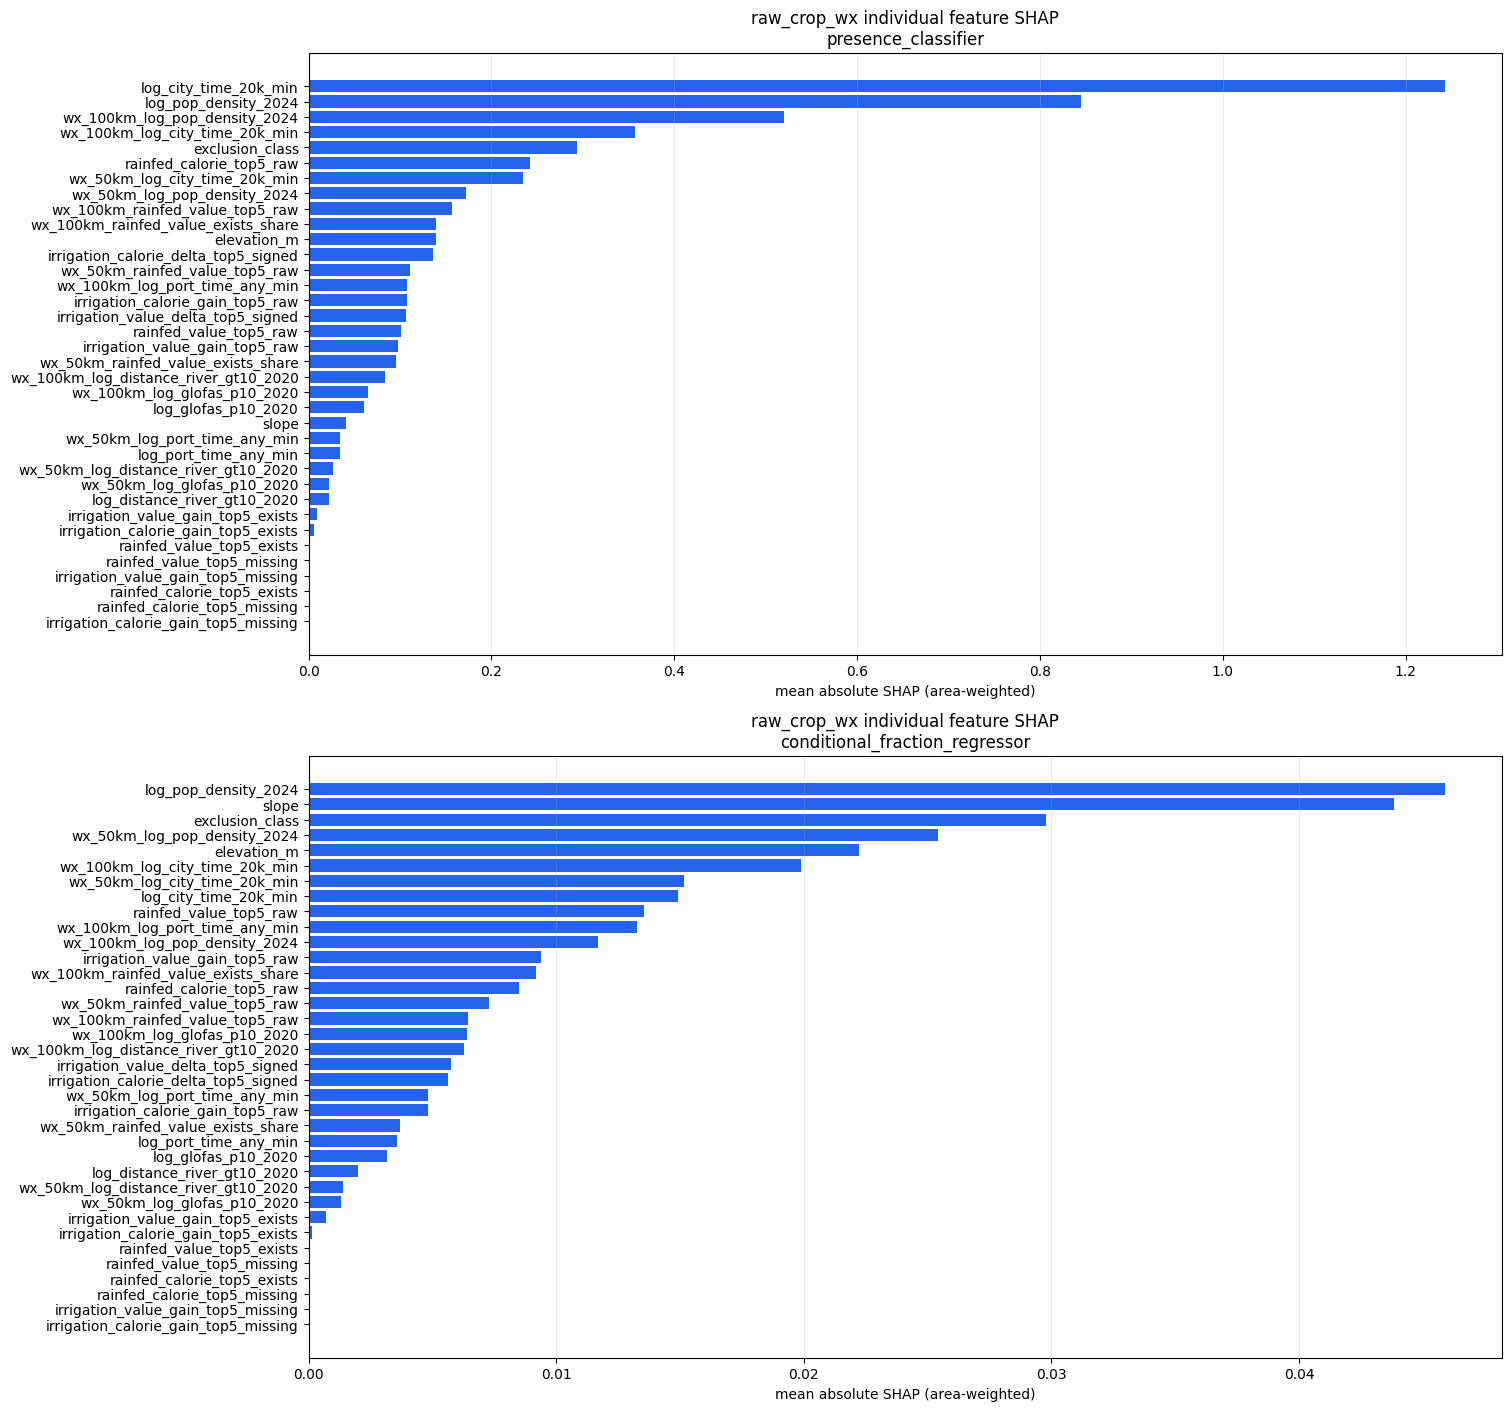

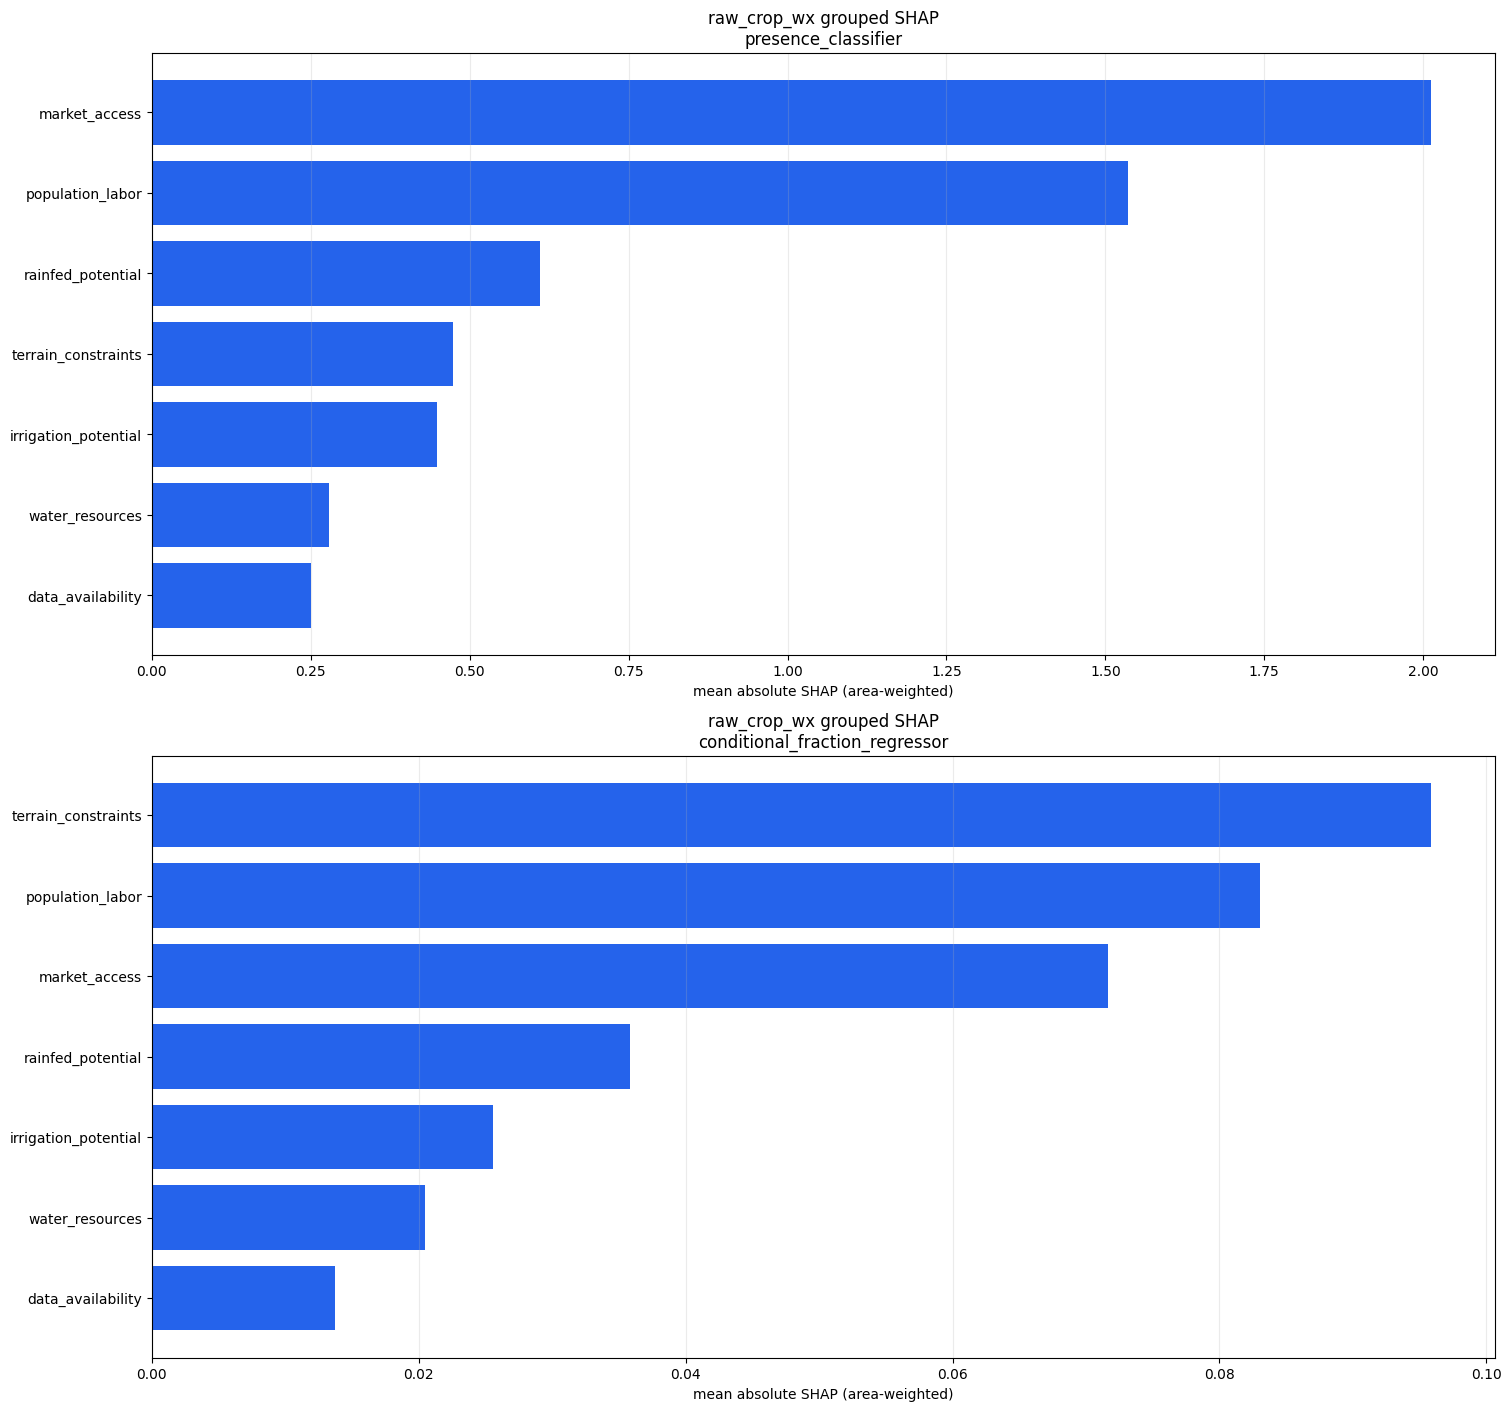


raw_crop_wx individual SHAP: top results
                         stage                               feature                group  mean_abs_shap  mean_signed_shap  relative_importance_share
conditional_fraction_regressor                  log_pop_density_2024     population_labor       0.045885          0.006960                   0.132572
conditional_fraction_regressor                                 slope  terrain_constraints       0.043818         -0.000165                   0.126600
conditional_fraction_regressor                       exclusion_class  terrain_constraints       0.029786          0.001035                   0.086057
conditional_fraction_regressor          wx_50km_log_pop_density_2024     population_labor       0.025434         -0.005766                   0.073484
conditional_fraction_regressor                           elevation_m  terrain_constraints       0.022228         -0.003259                   0.064222
conditional_fraction_regressor        wx_100km_log_city_ti

In [13]:
# ============================================================
# OOF SHAP分析：raw_crop_wx
# 個別変数別 + グループ別
# ============================================================

import gc
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier, LGBMRegressor


# ------------------------------------------------------------
# 設定
# ------------------------------------------------------------

RAW_WX_SHAP_MODEL = "raw_crop_wx"

# Noneにすると各foldの全テストデータを使用
# メモリ・計算時間を抑える場合は10000程度
RAW_WX_SHAP_MAX_ROWS_PER_FOLD = 10_000

RAW_WX_SHAP_DIR = OUTPUT_DIR / "oof_shap_raw_crop_wx"
RAW_WX_SHAP_DIR.mkdir(parents=True, exist_ok=True)

RAW_WX_SHAP_FEATURES = list(
    feature_cols_raw_by_model[RAW_WX_SHAP_MODEL]
)

RAW_WX_SHAP_REQUIRED = [
    "raw_analysis_sample",
    "feature_cols_raw_by_model",
    "splits",
    "N_SPLITS",
    "RANDOM_SEED",
    "OUTPUT_DIR",
]

missing_objects = [
    name
    for name in RAW_WX_SHAP_REQUIRED
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"不足している変数があります: {missing_objects}\n"
        "先にraw_crop / raw_crop_wx再推定セルまで実行してください。"
    )

if "area_weight" not in globals():
    area_weight = None


print("SHAP model:", RAW_WX_SHAP_MODEL)
print("feature count:", len(RAW_WX_SHAP_FEATURES))
print("output:", RAW_WX_SHAP_DIR)


# ------------------------------------------------------------
# グループ定義
# ------------------------------------------------------------

def raw_wx_shap_group(feature):
    feature = str(feature)

    # データの存在・欠測情報
    if (
        "exists" in feature
        or "missing" in feature
    ):
        return "data_availability"

    # 地形・制約条件
    if feature in {
        "elevation_m",
        "slope",
        "exclusion_class",
    }:
        return "terrain_constraints"

    # 人口・労働供給
    if "pop_density" in feature:
        return "population_labor"

    # 市場アクセス
    if (
        "city_time" in feature
        or "port_time" in feature
    ):
        return "market_access"

    # 水資源・河川条件
    if (
        "glofas" in feature
        or "distance_river" in feature
    ):
        return "water_resources"

    # 天水農業ポテンシャル
    if "rainfed" in feature:
        return "rainfed_potential"

    # 灌漑ポテンシャル
    if "irrigation" in feature:
        return "irrigation_potential"

    return "other"


RAW_WX_SHAP_GROUP_MAP = {
    feature: raw_wx_shap_group(feature)
    for feature in RAW_WX_SHAP_FEATURES
}

unknown_groups = [
    feature
    for feature, group in RAW_WX_SHAP_GROUP_MAP.items()
    if group == "other"
]

if unknown_groups:
    print("未分類の変数:", unknown_groups)


# ------------------------------------------------------------
# 補助関数
# ------------------------------------------------------------

def choose_raw_wx_shap_indices(
    indices,
    max_rows,
    seed,
):
    indices = np.asarray(indices, dtype=int)

    if (
        max_rows is None
        or len(indices) <= max_rows
    ):
        return np.sort(indices)

    rng = np.random.default_rng(seed)

    selected = rng.choice(
        indices,
        size=max_rows,
        replace=False,
    )

    return np.sort(selected)


def raw_wx_tree_shap(
    model,
    frame,
    features,
):
    X = frame[features]

    try:
        explainer = shap.TreeExplainer(
            model,
            feature_perturbation="tree_path_dependent",
            model_output="raw",
        )

        values = explainer.shap_values(
            X,
            check_additivity=False,
        )

    except Exception as error:
        print(
            "Tree SHAPの設定を変更して再試行:",
            repr(error),
        )

        explainer = shap.TreeExplainer(model)

        values = explainer.shap_values(
            X,
            check_additivity=False,
        )

    # 古いSHAPでは二値分類がlistで返る
    if isinstance(values, list):
        if len(values) == 2:
            values = values[1]
        else:
            values = values[0]

    values = np.asarray(values)

    # 新しいSHAPで shape=(n, features, classes) の場合
    if values.ndim == 3:
        values = values[:, :, -1]

    if values.ndim != 2:
        raise ValueError(
            f"予期しないSHAP shapeです: {values.shape}"
        )

    if values.shape[1] != len(features):
        raise ValueError(
            "SHAPの変数数が一致しません: "
            f"{values.shape} vs {len(features)}"
        )

    return values.astype(
        np.float32,
        copy=False,
    )


def fit_raw_wx_models(
    train_df,
    features,
    fold_number,
):
    classifier = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=4,
        verbose=-1,
    )

    classifier.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=["exclusion_class"],
    )

    positive_train = train_df[
        train_df["presence"].eq(1)
    ]

    regressor = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=4,
        verbose=-1,
    )

    regressor.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=["exclusion_class"],
    )

    return classifier, regressor


def raw_wx_shap_sufficient_statistics(
    values,
    sample_indices,
):
    values = np.asarray(values, dtype=float)

    if area_weight is None:
        weights = np.ones(
            len(sample_indices),
            dtype=float,
        )
    else:
        weights = np.asarray(
            area_weight,
            dtype=float,
        )[sample_indices]

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return {
            "n": 0,
            "weight_sum": 0.0,
            "sum_abs_unweighted": 0.0,
            "sum_signed_unweighted": 0.0,
            "sum_abs_weighted": 0.0,
            "sum_signed_weighted": 0.0,
        }

    return {
        "n": int(len(values)),
        "weight_sum": float(weights.sum()),
        "sum_abs_unweighted": float(
            np.abs(values).sum()
        ),
        "sum_signed_unweighted": float(
            values.sum()
        ),
        "sum_abs_weighted": float(
            np.sum(weights * np.abs(values))
        ),
        "sum_signed_weighted": float(
            np.sum(weights * values)
        ),
    }


def append_raw_wx_feature_rows(
    rows,
    shap_values,
    features,
    sample_indices,
    model_name,
    stage_name,
    fold_number,
):
    for feature_index, feature in enumerate(features):
        stats = raw_wx_shap_sufficient_statistics(
            shap_values[:, feature_index],
            sample_indices,
        )

        rows.append({
            "model": model_name,
            "stage": stage_name,
            "fold": fold_number,
            "feature": feature,
            **stats,
        })


def append_raw_wx_group_rows(
    rows,
    shap_values,
    features,
    sample_indices,
    model_name,
    stage_name,
    fold_number,
):
    group_names = sorted(
        set(
            RAW_WX_SHAP_GROUP_MAP.values()
        )
    )

    for group_name in group_names:
        group_features = [
            feature
            for feature in features
            if RAW_WX_SHAP_GROUP_MAP[feature]
            == group_name
        ]

        if len(group_features) == 0:
            continue

        feature_indices = [
            features.index(feature)
            for feature in group_features
        ]

        group_signed_values = (
            shap_values[:, feature_indices]
            .sum(axis=1)
        )

        # グループ内の各変数の絶対SHAPを合計
        group_absolute_values = (
            np.abs(
                shap_values[:, feature_indices]
            ).sum(axis=1)
        )

        signed_stats = (
            raw_wx_shap_sufficient_statistics(
                group_signed_values,
                sample_indices,
            )
        )

        absolute_stats = (
            raw_wx_shap_sufficient_statistics(
                group_absolute_values,
                sample_indices,
            )
        )

        rows.append({
            "model": model_name,
            "stage": stage_name,
            "fold": fold_number,
            "group": group_name,
            "group_features": "|".join(
                group_features
            ),
            "n": absolute_stats["n"],
            "weight_sum": absolute_stats["weight_sum"],
            "sum_abs_unweighted": (
                absolute_stats["sum_abs_unweighted"]
            ),
            "sum_signed_unweighted": (
                signed_stats["sum_signed_unweighted"]
            ),
            "sum_abs_weighted": (
                absolute_stats["sum_abs_weighted"]
            ),
            "sum_signed_weighted": (
                signed_stats["sum_signed_weighted"]
            ),
        })


def finalize_raw_wx_shap_summary(
    frame,
    key_column,
):
    sum_columns = [
        "n",
        "weight_sum",
        "sum_abs_unweighted",
        "sum_signed_unweighted",
        "sum_abs_weighted",
        "sum_signed_weighted",
    ]

    summary = (
        frame
        .groupby(
            [
                "model",
                "stage",
                key_column,
            ],
            as_index=False,
        )[sum_columns]
        .sum()
    )

    # 面積・抽出補正重み付きのSHAP
    summary["mean_abs_shap"] = (
        summary["sum_abs_weighted"]
        / summary["weight_sum"].replace(
            0,
            np.nan,
        )
    )

    summary["mean_signed_shap"] = (
        summary["sum_signed_weighted"]
        / summary["weight_sum"].replace(
            0,
            np.nan,
        )
    )

    # 単純平均のSHAP
    summary["mean_abs_shap_unweighted"] = (
        summary["sum_abs_unweighted"]
        / summary["n"].replace(
            0,
            np.nan,
        )
    )

    summary["mean_signed_shap_unweighted"] = (
        summary["sum_signed_unweighted"]
        / summary["n"].replace(
            0,
            np.nan,
        )
    )

    summary["relative_importance_share"] = (
        summary
        .groupby(
            ["model", "stage"]
        )["mean_abs_shap"]
        .transform(
            lambda values:
            values / values.sum()
        )
    )

    if key_column == "feature":
        summary["group"] = (
            summary["feature"]
            .map(RAW_WX_SHAP_GROUP_MAP)
        )

    if key_column == "group":
        group_feature_map = {}

        for group_name in set(
            RAW_WX_SHAP_GROUP_MAP.values()
        ):
            group_feature_map[group_name] = "|".join(
                [
                    feature
                    for feature in RAW_WX_SHAP_FEATURES
                    if RAW_WX_SHAP_GROUP_MAP[feature]
                    == group_name
                ]
            )

        summary["group_features"] = (
            summary["group"]
            .map(group_feature_map)
        )

    return summary.sort_values(
        [
            "model",
            "stage",
            "mean_abs_shap",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )


# ------------------------------------------------------------
# OOF SHAP計算
# ------------------------------------------------------------

raw_wx_feature_shap_fold_rows = []
raw_wx_group_shap_fold_rows = []

raw_wx_y = (
    raw_analysis_sample["presence"]
    .to_numpy(dtype=np.uint8)
)

for fold_number, (train_idx, test_idx) in enumerate(
    splits,
    start=1,
):
    print("=" * 70)
    print(
        f"RAW_CROP_WX SHAP FOLD "
        f"{fold_number}/{N_SPLITS}"
    )

    train_df = raw_analysis_sample.iloc[
        train_idx
    ].copy()

    classifier, regressor = fit_raw_wx_models(
        train_df,
        RAW_WX_SHAP_FEATURES,
        fold_number,
    )

    # --------------------------------------------------------
    # Stage 1: presence classifier
    # --------------------------------------------------------

    classifier_test_indices = (
        choose_raw_wx_shap_indices(
            test_idx,
            RAW_WX_SHAP_MAX_ROWS_PER_FOLD,
            RANDOM_SEED
            + 3000
            + fold_number,
        )
    )

    classifier_test_df = (
        raw_analysis_sample.iloc[
            classifier_test_indices
        ].copy()
    )

    classifier_shap_values = raw_wx_tree_shap(
        classifier,
        classifier_test_df,
        RAW_WX_SHAP_FEATURES,
    )

    append_raw_wx_feature_rows(
        raw_wx_feature_shap_fold_rows,
        classifier_shap_values,
        RAW_WX_SHAP_FEATURES,
        classifier_test_indices,
        RAW_WX_SHAP_MODEL,
        "presence_classifier",
        fold_number,
    )

    append_raw_wx_group_rows(
        raw_wx_group_shap_fold_rows,
        classifier_shap_values,
        RAW_WX_SHAP_FEATURES,
        classifier_test_indices,
        RAW_WX_SHAP_MODEL,
        "presence_classifier",
        fold_number,
    )

    del classifier_shap_values

    # --------------------------------------------------------
    # Stage 2: conditional fraction regressor
    # --------------------------------------------------------

    positive_test_indices = test_idx[
        raw_wx_y[test_idx] == 1
    ]

    positive_test_indices = (
        choose_raw_wx_shap_indices(
            positive_test_indices,
            RAW_WX_SHAP_MAX_ROWS_PER_FOLD,
            RANDOM_SEED
            + 4000
            + fold_number,
        )
    )

    if len(positive_test_indices) > 0:
        positive_test_df = (
            raw_analysis_sample.iloc[
                positive_test_indices
            ].copy()
        )

        regressor_shap_values = raw_wx_tree_shap(
            regressor,
            positive_test_df,
            RAW_WX_SHAP_FEATURES,
        )

        append_raw_wx_feature_rows(
            raw_wx_feature_shap_fold_rows,
            regressor_shap_values,
            RAW_WX_SHAP_FEATURES,
            positive_test_indices,
            RAW_WX_SHAP_MODEL,
            "conditional_fraction_regressor",
            fold_number,
        )

        append_raw_wx_group_rows(
            raw_wx_group_shap_fold_rows,
            regressor_shap_values,
            RAW_WX_SHAP_FEATURES,
            positive_test_indices,
            RAW_WX_SHAP_MODEL,
            "conditional_fraction_regressor",
            fold_number,
        )

        del regressor_shap_values

    del classifier
    del regressor
    gc.collect()


# ------------------------------------------------------------
# 集計
# ------------------------------------------------------------

raw_wx_feature_shap_fold = pd.DataFrame(
    raw_wx_feature_shap_fold_rows
)

raw_wx_group_shap_fold = pd.DataFrame(
    raw_wx_group_shap_fold_rows
)

raw_wx_feature_shap_summary = (
    finalize_raw_wx_shap_summary(
        raw_wx_feature_shap_fold,
        "feature",
    )
)

raw_wx_group_shap_summary = (
    finalize_raw_wx_shap_summary(
        raw_wx_group_shap_fold,
        "group",
    )
)


# ------------------------------------------------------------
# CSV保存
# ------------------------------------------------------------

raw_wx_feature_shap_summary.to_csv(
    RAW_WX_SHAP_DIR
    / "raw_crop_wx_individual_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

raw_wx_group_shap_summary.to_csv(
    RAW_WX_SHAP_DIR
    / "raw_crop_wx_group_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

raw_wx_feature_shap_fold.to_csv(
    RAW_WX_SHAP_DIR
    / "raw_crop_wx_individual_shap_fold.csv",
    index=False,
    encoding="utf-8-sig",
)

raw_wx_group_shap_fold.to_csv(
    RAW_WX_SHAP_DIR
    / "raw_crop_wx_group_shap_fold.csv",
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# 図の作成
# ------------------------------------------------------------

def plot_raw_wx_shap(
    summary,
    key_column,
    title,
    output_name,
    top_n=None,
):
    stages = [
        "presence_classifier",
        "conditional_fraction_regressor",
    ]

    fig, axes = plt.subplots(
        len(stages),
        1,
        figsize=(15, 7 * len(stages)),
        squeeze=False,
        constrained_layout=True,
    )

    for row_index, stage_name in enumerate(stages):
        ax = axes[row_index, 0]

        plot_df = summary[
            summary["stage"] == stage_name
        ].copy()

        plot_df = plot_df.sort_values(
            "mean_abs_shap",
            ascending=True,
        )

        if top_n is not None:
            plot_df = plot_df.tail(top_n)

        ax.barh(
            plot_df[key_column].astype(str),
            plot_df["mean_abs_shap"],
            color="#2563eb",
        )

        ax.set_title(
            f"{title}\n{stage_name}"
        )

        ax.set_xlabel(
            "mean absolute SHAP "
            "(area-weighted)"
        )

        ax.grid(
            axis="x",
            alpha=0.25,
        )

    figure_path = (
        RAW_WX_SHAP_DIR
        / output_name
    )

    fig.savefig(
        figure_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

    return figure_path


raw_wx_individual_figure = plot_raw_wx_shap(
    raw_wx_feature_shap_summary,
    key_column="feature",
    title="raw_crop_wx individual feature SHAP",
    output_name="raw_crop_wx_individual_shap.png",
    top_n=None,
)

raw_wx_group_figure = plot_raw_wx_shap(
    raw_wx_group_shap_summary,
    key_column="group",
    title="raw_crop_wx grouped SHAP",
    output_name="raw_crop_wx_group_shap.png",
    top_n=None,
)


# ------------------------------------------------------------
# 結果表示
# ------------------------------------------------------------

print()
print("=" * 70)
print("raw_crop_wx individual SHAP: top results")
print("=" * 70)

print(
    raw_wx_feature_shap_summary[
        [
            "stage",
            "feature",
            "group",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ]
    .round(6)
    .to_string(index=False)
)

print()
print("=" * 70)
print("raw_crop_wx grouped SHAP: top results")
print("=" * 70)

print(
    raw_wx_group_shap_summary[
        [
            "stage",
            "group",
            "group_features",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ]
    .round(6)
    .to_string(index=False)
)

print()
print("保存先:")
print(RAW_WX_SHAP_DIR)
print("個別変数図:", raw_wx_individual_figure)
print("グループ図:", raw_wx_group_figure)

## 24いくつかの状態を想定した方が精度が上がるか？

In [1]:
# ============================================================
# 【セル24】農業レジーム分割モデルの空間OOF比較
# ============================================================

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder


print("=" * 80)
print("REGIME-SPECIFIC MODEL VS POOLED MODEL")
print("=" * 80)


# ------------------------------------------------------------
# 0. 前提確認
# ------------------------------------------------------------

_required_objects = [
    "raw_analysis_sample",
    "raw_oof",
    "feature_cols_raw_by_model",
    "splits",
    "fit_predict_two_stage",
    "adjust_probability_prior_shift",
]

_missing_objects = [
    name for name in _required_objects
    if name not in globals()
]

if _missing_objects:
    raise RuntimeError(
        "先にセル21・23を実行してください。"
        f"不足している変数: {_missing_objects}"
    )


REGIME_MODEL_NAME = "raw_crop_wx"

# 最初は2〜4で十分です。
# 必要なら後で5を追加してください。
REGIME_K_VALUES = (2, 3, 4)

REGIME_RANDOM_SEED = RANDOM_SEED + 5000
REGIME_MIN_TRAIN_ROWS = 2_000
REGIME_MIN_TRAIN_POSITIVE = 200
REGIME_MIN_TRAIN_NEGATIVE = 200

REGIME_OUTPUT_DIR = OUTPUT_DIR / "regime_model_comparison"
REGIME_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. レジーム分類に使う変数
# ------------------------------------------------------------

# raw_crop_wxの説明変数を候補にする。
# ただし、データの有無を表す変数はレジーム分類から除外する。
# これは「データがある地域」と「農業レジーム」を混同しないため。
all_model_features = list(
    feature_cols_raw_by_model[REGIME_MODEL_NAME]
)

REGIME_CATEGORICAL_COLS = [
    col
    for col in ["exclusion_class"]
    if col in all_model_features
]

REGIME_NUMERIC_COLS = [
    col
    for col in all_model_features
    if col not in REGIME_CATEGORICAL_COLS
    and "exists" not in col.lower()
    and "missing" not in col.lower()
]

REGIME_FEATURE_COLS = (
    REGIME_NUMERIC_COLS
    + REGIME_CATEGORICAL_COLS
)

if len(REGIME_NUMERIC_COLS) == 0:
    raise RuntimeError("レジーム分類用の数値変数がありません。")

print()
print("Regime numeric features:")
print(REGIME_NUMERIC_COLS)

print()
print("Regime categorical features:")
print(REGIME_CATEGORICAL_COLS)


# ------------------------------------------------------------
# 2. レジーム分類用の前処理
# ------------------------------------------------------------

def make_regime_matrices(train_df, test_df):
    """
    trainデータだけで標準化・カテゴリ変換を学習し、
    testデータに適用する。
    """

    X_train_num = train_df[
        REGIME_NUMERIC_COLS
    ].to_numpy(dtype=np.float32)

    X_test_num = test_df[
        REGIME_NUMERIC_COLS
    ].to_numpy(dtype=np.float32)

    if not np.isfinite(X_train_num).all():
        raise ValueError(
            "レジーム分類用train変数にNaNまたはinfがあります。"
        )

    if not np.isfinite(X_test_num).all():
        raise ValueError(
            "レジーム分類用test変数にNaNまたはinfがあります。"
        )

    scaler = StandardScaler()

    X_train_num = scaler.fit_transform(
        X_train_num
    ).astype(np.float32)

    X_test_num = scaler.transform(
        X_test_num
    ).astype(np.float32)

    matrices_train = [X_train_num]
    matrices_test = [X_test_num]

    if len(REGIME_CATEGORICAL_COLS) > 0:

        train_cat = train_df[
            REGIME_CATEGORICAL_COLS
        ].astype(str)

        test_cat = test_df[
            REGIME_CATEGORICAL_COLS
        ].astype(str)

        try:
            encoder = OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            )
        except TypeError:
            # 古いscikit-learn用
            encoder = OneHotEncoder(
                handle_unknown="ignore",
                sparse=False,
            )

        X_train_cat = encoder.fit_transform(
            train_cat
        ).astype(np.float32)

        X_test_cat = encoder.transform(
            test_cat
        ).astype(np.float32)

        matrices_train.append(X_train_cat)
        matrices_test.append(X_test_cat)

    X_train = np.hstack(
        matrices_train
    ).astype(np.float32)

    X_test = np.hstack(
        matrices_test
    ).astype(np.float32)

    return X_train, X_test


# ------------------------------------------------------------
# 3. レジーム内の存在確率を補正するための事前確率
# ------------------------------------------------------------

def estimate_regime_target_prior(
    train_df,
    train_global_indices,
):
    """
    レジーム内の農地存在確率を推定する。

    area_weightがある場合は面積加重、
    ない場合はtrain内の単純平均を使用する。
    """

    y = train_df[
        "presence"
    ].to_numpy(dtype=float)

    if area_weight is None:
        return float(np.mean(y))

    w = np.asarray(
        area_weight,
        dtype=float,
    )[train_global_indices]

    valid = (
        np.isfinite(y)
        & np.isfinite(w)
        & (w > 0)
    )

    if valid.sum() == 0:
        return float(np.mean(y))

    return float(
        np.average(
            y[valid],
            weights=w[valid],
        )
    )


# ------------------------------------------------------------
# 4. レジーム内用の二段階LightGBM
# ------------------------------------------------------------

def fit_predict_two_stage_regime(
    train_df,
    test_df,
    features,
    fold_number,
    regime_id,
    target_prior_regime,
):

    categorical_features = [
        col
        for col in ["exclusion_class"]
        if col in features
    ]

    random_state = (
        RANDOM_SEED
        + fold_number * 1000
        + regime_id
    )

    # -------------------------
    # Stage 1: presence
    # -------------------------

    clf = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=random_state,
        n_jobs=4,
        verbose=-1,
    )

    clf.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=categorical_features,
    )

    raw_probability = clf.predict_proba(
        test_df[features]
    )[:, 1]

    train_sample_prior = float(
        train_df["presence"].mean()
    )

    calibrated_probability = (
        adjust_probability_prior_shift(
            raw_probability,
            train_sample_prior,
            target_prior_regime,
        )
    )

    # -------------------------
    # Stage 2: conditional fraction
    # -------------------------

    positive_train = train_df[
        train_df["presence"].eq(1)
    ]

    reg = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=random_state + 100,
        n_jobs=4,
        verbose=-1,
    )

    reg.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=categorical_features,
    )

    conditional_fraction = np.clip(
        reg.predict(test_df[features]),
        0,
        1,
    )

    expected_fraction = (
        calibrated_probability
        * conditional_fraction
    )

    return (
        raw_probability,
        calibrated_probability,
        conditional_fraction,
        expected_fraction,
    )


# ------------------------------------------------------------
# 5. 評価関数
# ------------------------------------------------------------

def regime_regression_metrics(
    y_true,
    y_pred,
    weights=None,
):

    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    if weights is None:
        weights = np.ones(
            len(y_true),
            dtype=float,
        )
    else:
        weights = np.asarray(
            weights,
            dtype=float,
        )

    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
        & np.isfinite(weights)
        & (weights > 0)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]
    weights = weights[valid]

    mean_true = np.average(
        y_true,
        weights=weights,
    )

    residual = y_true - y_pred

    ss_res = np.sum(
        weights * residual**2
    )

    ss_tot = np.sum(
        weights * (y_true - mean_true)**2
    )

    return {
        "n": int(len(y_true)),
        "r2": float(
            1 - ss_res / ss_tot
        ) if ss_tot > 0 else np.nan,
        "rmse": float(
            np.sqrt(
                np.average(
                    residual**2,
                    weights=weights,
                )
            )
        ),
        "mae": float(
            np.average(
                np.abs(residual),
                weights=weights,
            )
        ),
        "observed_mean": float(mean_true),
        "predicted_mean": float(
            np.average(
                y_pred,
                weights=weights,
            )
        ),
    }


# ------------------------------------------------------------
# 6. データ・OOF予測の準備
# ------------------------------------------------------------

y_fraction_regime = raw_analysis_sample[
    "cropland_fraction"
].to_numpy(dtype=float)

pooled_prediction = raw_oof[
    REGIME_MODEL_NAME
]["fraction_expected"]

pooled_fold = raw_oof[
    REGIME_MODEL_NAME
]["fold"]

if len(raw_analysis_sample) != len(pooled_prediction):
    raise RuntimeError(
        "raw_analysis_sampleとraw_oofの行数が一致していません。"
    )

weighting_specs_regime = {
    "unweighted_sample": None,
}

if area_weight is not None:
    weighting_specs_regime[
        "area_weighted_reweighted"
    ] = np.asarray(
        area_weight,
        dtype=float,
    )


# ------------------------------------------------------------
# 7. Kごとにレジーム別モデルをOOF推定
# ------------------------------------------------------------

regime_predictions = {}
regime_labels = {}

regime_distribution_rows = []

for n_regimes in REGIME_K_VALUES:

    print()
    print("=" * 80)
    print(
        f"REGIME-SPECIFIC OOF MODEL: "
        f"K={n_regimes}"
    )
    print("=" * 80)

    regime_prediction = np.full(
        len(raw_analysis_sample),
        np.nan,
        dtype=np.float32,
    )

    regime_label_oof = np.full(
        len(raw_analysis_sample),
        -1,
        dtype=np.int16,
    )

    candidate_distribution_rows = []
    candidate_failed = False
    failure_reason = None

    for fold_number, (
        train_idx,
        test_idx,
    ) in enumerate(
        splits,
        start=1,
    ):

        print()
        print(
            f"Fold {fold_number}/{N_SPLITS}"
        )

        train_df = raw_analysis_sample.iloc[
            train_idx
        ]

        test_df = raw_analysis_sample.iloc[
            test_idx
        ]

        # train foldだけでレジーム分類用変換を学習
        X_train_regime, X_test_regime = (
            make_regime_matrices(
                train_df,
                test_df,
            )
        )

        cluster_model = MiniBatchKMeans(
            n_clusters=n_regimes,
            random_state=(
                REGIME_RANDOM_SEED
                + fold_number
                + n_regimes * 100
            ),
            batch_size=8192,
            n_init=10,
            max_iter=100,
            reassignment_ratio=0.01,
        )

        train_regime_labels = (
            cluster_model.fit_predict(
                X_train_regime
            )
        )

        test_regime_labels = (
            cluster_model.predict(
                X_test_regime
            )
        )

        # 各レジームのtrainデータ量を確認
        for regime_id in range(n_regimes):

            train_regime_mask = (
                train_regime_labels
                == regime_id
            )

            test_regime_mask = (
                test_regime_labels
                == regime_id
            )

            train_n = int(
                train_regime_mask.sum()
            )

            test_n = int(
                test_regime_mask.sum()
            )

            train_positive_n = int(
                (
                    train_regime_mask
                    & (
                        train_df[
                            "presence"
                        ].to_numpy()
                        == 1
                    )
                ).sum()
            )

            train_negative_n = int(
                (
                    train_regime_mask
                    & (
                        train_df[
                            "presence"
                        ].to_numpy()
                        == 0
                    )
                ).sum()
            )

            candidate_distribution_rows.append({
                "k": n_regimes,
                "fold": fold_number,
                "regime_id": regime_id,
                "train_n": train_n,
                "test_n": test_n,
                "train_positive_n": train_positive_n,
                "train_negative_n": train_negative_n,
            })

            if test_n == 0:
                continue

            if train_n < REGIME_MIN_TRAIN_ROWS:
                candidate_failed = True
                failure_reason = (
                    f"K={n_regimes}, fold={fold_number}, "
                    f"regime={regime_id}: "
                    f"train_n={train_n}"
                )

            if train_positive_n < (
                REGIME_MIN_TRAIN_POSITIVE
            ):
                candidate_failed = True
                failure_reason = (
                    f"K={n_regimes}, fold={fold_number}, "
                    f"regime={regime_id}: "
                    f"positive_n={train_positive_n}"
                )

            if train_negative_n < (
                REGIME_MIN_TRAIN_NEGATIVE
            ):
                candidate_failed = True
                failure_reason = (
                    f"K={n_regimes}, fold={fold_number}, "
                    f"regime={regime_id}: "
                    f"negative_n={train_negative_n}"
                )

        if candidate_failed:
            break

        # レジームごとに別々の二段階モデルを学習
        for regime_id in range(n_regimes):

            train_regime_mask = (
                train_regime_labels
                == regime_id
            )

            test_regime_mask = (
                test_regime_labels
                == regime_id
            )

            if not test_regime_mask.any():
                continue

            regime_train_df = train_df.iloc[
                train_regime_mask
            ]

            regime_test_df = test_df.iloc[
                test_regime_mask
            ]

            regime_train_global_indices = (
                train_idx[train_regime_mask]
            )

            regime_target_prior = (
                estimate_regime_target_prior(
                    regime_train_df,
                    regime_train_global_indices,
                )
            )

            (
                raw_probability,
                calibrated_probability,
                conditional_fraction,
                expected_fraction,
            ) = fit_predict_two_stage_regime(
                regime_train_df,
                regime_test_df,
                feature_cols_raw_by_model[
                    REGIME_MODEL_NAME
                ],
                fold_number,
                regime_id,
                regime_target_prior,
            )

            target_global_indices = (
                test_idx[test_regime_mask]
            )

            regime_prediction[
                target_global_indices
            ] = expected_fraction

            regime_label_oof[
                target_global_indices
            ] = regime_id

            del (
                raw_probability,
                calibrated_probability,
                conditional_fraction,
                expected_fraction,
            )

        del (
            X_train_regime,
            X_test_regime,
            cluster_model,
        )

        gc.collect()

    if candidate_failed:
        print()
        print(
            f"SKIP K={n_regimes}: "
            f"{failure_reason}"
        )
        continue

    if not np.isfinite(
        regime_prediction
    ).all():
        raise RuntimeError(
            f"K={n_regimes}でOOF予測が完成していません。"
        )

    if (regime_label_oof < 0).any():
        raise RuntimeError(
            f"K={n_regimes}でレジームラベルが未割当です。"
        )

    regime_predictions[
        n_regimes
    ] = regime_prediction

    regime_labels[
        n_regimes
    ] = regime_label_oof

    regime_distribution_rows.extend(
        candidate_distribution_rows
    )

    print(
        f"K={n_regimes} completed."
    )


# ------------------------------------------------------------
# 8. pooledモデルとレジーム別モデルの比較
# ------------------------------------------------------------

candidate_metrics_rows = []

for n_regimes, regime_prediction in (
    regime_predictions.items()
):

    for weighting_name, weights in (
        weighting_specs_regime.items()
    ):

        regime_result = regime_regression_metrics(
            y_fraction_regime,
            regime_prediction,
            weights=weights,
        )

        pooled_result = regime_regression_metrics(
            y_fraction_regime,
            pooled_prediction,
            weights=weights,
        )

        candidate_metrics_rows.append({
            "k": n_regimes,
            "weighting": weighting_name,
            "regime_model_r2": regime_result["r2"],
            "pooled_model_r2": pooled_result["r2"],
            "delta_r2": (
                regime_result["r2"]
                - pooled_result["r2"]
            ),
            "regime_model_rmse": regime_result["rmse"],
            "pooled_model_rmse": pooled_result["rmse"],
            "delta_rmse": (
                regime_result["rmse"]
                - pooled_result["rmse"]
            ),
            "regime_model_mae": regime_result["mae"],
            "pooled_model_mae": pooled_result["mae"],
            "delta_mae": (
                regime_result["mae"]
                - pooled_result["mae"]
            ),
        })


regime_candidate_metrics_df = pd.DataFrame(
    candidate_metrics_rows
)

print()
print("=" * 80)
print("POOLED VS REGIME-SPECIFIC GLOBAL METRICS")
print("=" * 80)

print(
    regime_candidate_metrics_df[
        [
            "k",
            "weighting",
            "regime_model_r2",
            "pooled_model_r2",
            "delta_r2",
            "regime_model_rmse",
            "pooled_model_rmse",
            "delta_rmse",
            "regime_model_mae",
            "pooled_model_mae",
            "delta_mae",
        ]
    ].round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 9. fold別の比較
# ------------------------------------------------------------

regime_fold_metrics_rows = []

for n_regimes, regime_prediction in (
    regime_predictions.items()
):

    for fold_number in range(
        1,
        N_SPLITS + 1,
    ):

        fold_mask = (
            pooled_fold
            == fold_number
        )

        for weighting_name, weights in (
            weighting_specs_regime.items()
        ):

            if weights is None:
                fold_weights = None
            else:
                fold_weights = weights[
                    fold_mask
                ]

            regime_result = regime_regression_metrics(
                y_fraction_regime[
                    fold_mask
                ],
                regime_prediction[
                    fold_mask
                ],
                weights=fold_weights,
            )

            pooled_result = regime_regression_metrics(
                y_fraction_regime[
                    fold_mask
                ],
                pooled_prediction[
                    fold_mask
                ],
                weights=fold_weights,
            )

            regime_fold_metrics_rows.append({
                "k": n_regimes,
                "fold": fold_number,
                "weighting": weighting_name,
                "regime_model_r2": regime_result["r2"],
                "pooled_model_r2": pooled_result["r2"],
                "delta_r2": (
                    regime_result["r2"]
                    - pooled_result["r2"]
                ),
                "regime_model_rmse": regime_result["rmse"],
                "pooled_model_rmse": pooled_result["rmse"],
                "delta_rmse": (
                    regime_result["rmse"]
                    - pooled_result["rmse"]
                ),
                "regime_model_mae": regime_result["mae"],
                "pooled_model_mae": pooled_result["mae"],
                "delta_mae": (
                    regime_result["mae"]
                    - pooled_result["mae"]
                ),
            })


regime_fold_metrics_df = pd.DataFrame(
    regime_fold_metrics_rows
)

print()
print("=" * 80)
print("FOLD-BY-FOLD DELTA R2")
print("=" * 80)

print(
    regime_fold_metrics_df[
        [
            "k",
            "fold",
            "weighting",
            "regime_model_r2",
            "pooled_model_r2",
            "delta_r2",
        ]
    ].round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 10. fold平均・標準偏差
# ------------------------------------------------------------

regime_fold_summary_df = (
    regime_fold_metrics_df
    .groupby(
        ["k", "weighting"],
        as_index=False,
    )
    .agg(
        mean_regime_r2=(
            "regime_model_r2",
            "mean",
        ),
        sd_regime_r2=(
            "regime_model_r2",
            "std",
        ),
        mean_pooled_r2=(
            "pooled_model_r2",
            "mean",
        ),
        mean_delta_r2=(
            "delta_r2",
            "mean",
        ),
        sd_delta_r2=(
            "delta_r2",
            "std",
        ),
        min_delta_r2=(
            "delta_r2",
            "min",
        ),
        max_delta_r2=(
            "delta_r2",
            "max",
        ),
    )
)

print()
print("=" * 80)
print("FOLD-MEAN SUMMARY")
print("=" * 80)

print(
    regime_fold_summary_df.round(6).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 11. レジーム別のOOF結果を保存
# ------------------------------------------------------------

regime_oof_table = raw_analysis_sample[
    [
        "row",
        "col",
        "lat",
        "lon",
        "spatial_block",
        "presence",
        "cropland_fraction",
    ]
].copy()

regime_oof_table[
    "pooled_raw_crop_wx_prediction"
] = pooled_prediction

regime_oof_table[
    "pooled_raw_crop_wx_residual"
] = (
    regime_oof_table[
        "cropland_fraction"
    ].to_numpy(dtype=float)
    - pooled_prediction
)

for n_regimes, prediction in (
    regime_predictions.items()
):

    regime_oof_table[
        f"regime_k{n_regimes}_prediction"
    ] = prediction

    regime_oof_table[
        f"regime_k{n_regimes}_residual"
    ] = (
        regime_oof_table[
            "cropland_fraction"
        ].to_numpy(dtype=float)
        - prediction
    )

    regime_oof_table[
        f"regime_k{n_regimes}_id"
    ] = regime_labels[
        n_regimes
    ]


regime_distribution_df = pd.DataFrame(
    regime_distribution_rows
)


# ------------------------------------------------------------
# 12. 保存
# ------------------------------------------------------------

regime_candidate_metrics_df.to_csv(
    REGIME_OUTPUT_DIR
    / "regime_candidate_global_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

regime_fold_metrics_df.to_csv(
    REGIME_OUTPUT_DIR
    / "regime_candidate_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

regime_fold_summary_df.to_csv(
    REGIME_OUTPUT_DIR
    / "regime_candidate_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

regime_oof_table.to_csv(
    REGIME_OUTPUT_DIR
    / "regime_candidate_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

regime_distribution_df.to_csv(
    REGIME_OUTPUT_DIR
    / "regime_candidate_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# 13. 最も良いKを表示
# ------------------------------------------------------------

print()
print("=" * 80)
print("BEST REGIME COUNT BY WEIGHTING")
print("=" * 80)

for weighting_name in weighting_specs_regime:

    subset = regime_candidate_metrics_df[
        regime_candidate_metrics_df[
            "weighting"
        ] == weighting_name
    ].copy()

    if len(subset) == 0:
        continue

    best_row = subset.loc[
        subset["delta_r2"].idxmax()
    ]

    print()
    print(
        f"[{weighting_name}]"
    )
    print(
        f"best K: {int(best_row['k'])}"
    )
    print(
        f"pooled R2: "
        f"{best_row['pooled_model_r2']:.6f}"
    )
    print(
        f"regime-specific R2: "
        f"{best_row['regime_model_r2']:.6f}"
    )
    print(
        f"delta R2: "
        f"{best_row['delta_r2']:.6f}"
    )

print()
print("保存先:")
print(REGIME_OUTPUT_DIR)

REGIME-SPECIFIC MODEL VS POOLED MODEL


RuntimeError: 先にセル21・23を実行してください。不足している変数: ['raw_analysis_sample', 'raw_oof', 'feature_cols_raw_by_model', 'splits', 'fit_predict_two_stage', 'adjust_probability_prior_shift']